# Barcelona Sustainable Tourism Pressure Analysis

This notebook builds a reproducible evidence base for the assignment **A Data-Driven Critical Appraisal of Sustainable Tourism Management in Barcelona: Tourism Pressure, Spatial Inequality and Policy Effectiveness**.

Workflow: inventory and profile all prepared files, standardise geography and dates, add official population denominators, aggregate the tourism/environment datasets, calculate pressure indicators, build an available-data Tourism Pressure Index, and export formal tables plus watermarked figures.

In [15]:
from pathlib import Path
from datetime import datetime
import json
import math
import re
import unicodedata
import urllib.request
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon as MplPolygon
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

try:
    from tabulate import tabulate
except ImportError:
    tabulate = None

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)

ROOT = Path.cwd().resolve()
if not (ROOT / "Data").exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / "Data"
CATALOG_DIR = DATA_DIR / "catalog"
PREPARED_DIR = DATA_DIR / "prepared"
OUTPUT_DIR = ROOT / "outputs"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"
CACHE_DIR = PREPARED_DIR / "supplementary" / "open_data_bcn"
for directory in (OUTPUT_DIR, TABLES_DIR, FIGURES_DIR, CACHE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

WATERMARK_TEXT = "created by Ioannis Kapetankis"
ANALYSIS_YEAR = 2025

print(f"Project root: {ROOT}")
print(f"Prepared data: {PREPARED_DIR}")
print(f"Outputs: {OUTPUT_DIR}")

Project root: D:\OneDrive - New York College\nyc hons hospitalty managment\semster 6\sus\Code
Prepared data: D:\OneDrive - New York College\nyc hons hospitalty managment\semster 6\sus\Code\Data\prepared
Outputs: D:\OneDrive - New York College\nyc hons hospitalty managment\semster 6\sus\Code\outputs


In [16]:
def unaccent(value):
    if pd.isna(value):
        return np.nan
    text = unicodedata.normalize("NFKD", str(value))
    return "".join(char for char in text if not unicodedata.combining(char))


def clean_text(value):
    if pd.isna(value):
        return np.nan
    text = unicodedata.normalize("NFKC", str(value))
    text = re.sub(r"\s+", " ", text.replace("\ufeff", "")).strip()
    if text in {"", "nan", "None", ".."}:
        return np.nan
    return text


def geo_key(value):
    text = unaccent(clean_text(value))
    if pd.isna(text):
        return np.nan
    text = re.sub(r"[^0-9a-zA-Z]+", " ", str(text).lower()).strip()
    return re.sub(r"\s+", " ", text)


def slugify(value):
    text = geo_key(value)
    if pd.isna(text):
        return "table"
    return re.sub(r"[^0-9a-zA-Z]+", "_", text).strip("_")


def standardize_columns(frame):
    frame = frame.copy()
    frame.columns = [
        re.sub(r"_+", "_", re.sub(r"[^0-9a-zA-Z]+", "_", unaccent(col)).strip("_").lower())
        for col in frame.columns
    ]
    return frame


def read_csv_any(path_or_url, **kwargs):
    encodings = ["utf-8-sig", "utf-8", "cp1252", "latin-1"]
    separators = [None, ";", ",", "\t"]
    best = None
    best_score = (-1, -1, -1)
    errors = []
    for encoding in encodings:
        for separator in separators:
            read_kwargs = {"encoding": encoding, "encoding_errors": "replace", "on_bad_lines": "skip"}
            if separator is None:
                read_kwargs.update({"sep": None, "engine": "python"})
            else:
                read_kwargs.update({"sep": separator})
            read_kwargs.update(kwargs)
            try:
                frame = pd.read_csv(path_or_url, **read_kwargs)
            except Exception as exc:
                errors.append(f"{encoding}/{separator}: {exc}")
                continue
            if frame.empty and len(frame.columns) == 0:
                continue
            semicolon_header = len(frame.columns) == 1 and ";" in str(frame.columns[0])
            unnamed = sum(str(col).lower().startswith("unnamed") for col in frame.columns)
            score = (0 if semicolon_header else frame.shape[1], -unnamed, frame.shape[0])
            if score > best_score:
                best = frame
                best_score = score
    if best is None:
        raise ValueError(f"Could not read {path_or_url}. Attempts: {' | '.join(errors[:5])}")
    return best


def first_path(pattern):
    matches = sorted(PREPARED_DIR.glob(pattern))
    if not matches:
        raise FileNotFoundError(f"No prepared file matched {pattern}")
    return matches[0]


def all_paths(pattern):
    return sorted(PREPARED_DIR.glob(pattern))


def to_number(series):
    if series is None:
        return pd.Series(dtype="float64")
    text = series.astype("string").str.strip()
    text = text.str.replace("\u00a0", "", regex=False)
    text = text.str.replace(r"[^0-9,\.\-]", "", regex=True)
    has_comma_decimal = text.str.contains(",", na=False) & ~text.str.contains(r"\.\d{1,3}$", na=False)
    text = text.where(~has_comma_decimal, text.str.replace(".", "", regex=False).str.replace(",", ".", regex=False))
    text = text.where(has_comma_decimal, text.str.replace(",", "", regex=False))
    return pd.to_numeric(text, errors="coerce")


def pick_col(frame, candidates, contains=None):
    columns = list(frame.columns)
    norm = {geo_key(col).replace(" ", "_"): col for col in columns}
    for candidate in candidates:
        key = geo_key(candidate).replace(" ", "_")
        if key in norm:
            return norm[key]
    if contains:
        tokens = [geo_key(token).replace(" ", "_") for token in contains]
        for col in columns:
            key = geo_key(col).replace(" ", "_")
            if all(token in key for token in tokens):
                return col
    return None


def coalesce_columns(frame, candidates):
    result = pd.Series(pd.NA, index=frame.index, dtype="object")
    for candidate in candidates:
        col = pick_col(frame, [candidate])
        if col is not None:
            result = result.fillna(frame[col].map(clean_text))
    return result


def first_valid(series):
    values = series.dropna()
    return values.iloc[0] if not values.empty else np.nan


def extract_year_from_text(value):
    match = re.search(r"(20\d{2})", str(value))
    return int(match.group(1)) if match else np.nan


def extract_quarter_from_text(value):
    match = re.search(r"(20\d{2})[_\- ]?([1-4])t", str(value).lower())
    return f"{match.group(1)} Q{match.group(2)}" if match else np.nan


def safe_date(series):
    return pd.to_datetime(series, errors="coerce", dayfirst=False)


def date_summary(frame):
    candidates = [col for col in frame.columns if any(token in col for token in ["date", "data", "period", "review"])]
    best = None
    best_count = 0
    for col in candidates:
        parsed = safe_date(frame[col])
        count = parsed.notna().sum()
        if count > best_count:
            best = parsed
            best_count = count
    if best is None or best_count == 0:
        return pd.Series({"date_min": pd.NaT, "date_max": pd.NaT})
    return pd.Series({"date_min": best.min(), "date_max": best.max()})


def profile_frame(name, frame, source="prepared"):
    dates = date_summary(frame)
    return {
        "dataset": name,
        "source": source,
        "rows": int(len(frame)),
        "columns": int(frame.shape[1]),
        "missing_cells": int(frame.isna().sum().sum()),
        "missing_pct": round(float(frame.isna().sum().sum() / max(frame.size, 1) * 100), 2),
        "date_min": dates["date_min"],
        "date_max": dates["date_max"],
        "column_names": ", ".join(map(str, frame.columns[:30])),
    }


def formal_table(frame, title, max_rows=20, tablefmt="github"):
    display(Markdown(f"**{title}**"))
    shown = frame.head(max_rows).copy()
    if tabulate is None:
        display(shown)
        return
    display(Markdown(tabulate(shown, headers="keys", tablefmt=tablefmt, showindex=False)))


def save_table(frame, name):
    path = TABLES_DIR / f"{slugify(name)}.csv"
    frame.to_csv(path, index=False, encoding="utf-8-sig")
    return path


def load_many(paths, source_name):
    frames = []
    for path in paths:
        frame = standardize_columns(read_csv_any(path))
        frame["source_file"] = path.name
        frame["source_path"] = str(path.relative_to(ROOT))
        frame["source_group"] = source_name
        frames.append(frame)
    return pd.concat(frames, ignore_index=True, sort=False) if frames else pd.DataFrame()


def download_cached(url, filename):
    target = CACHE_DIR / filename
    if target.exists() and target.stat().st_size > 0:
        return target
    try:
        urllib.request.urlretrieve(url, target)
    except Exception as exc:
        warnings.warn(f"Could not download {url}: {exc}")
        return target if target.exists() else None
    return target


def zscore(series):
    numeric = pd.to_numeric(series, errors="coerce")
    std = numeric.std(ddof=0)
    if pd.isna(std) or std == 0:
        return pd.Series(0.0, index=series.index)
    return (numeric - numeric.mean()) / std


def gini(values):
    array = np.asarray(pd.to_numeric(pd.Series(values), errors="coerce").fillna(0), dtype=float)
    if array.size == 0 or np.all(array == 0):
        return 0.0
    array = np.sort(array)
    index = np.arange(1, array.size + 1)
    return float((2 * np.sum(index * array) / (array.size * np.sum(array))) - ((array.size + 1) / array.size))


def concentration_stats(frame, value_col, label):
    values = frame[value_col].fillna(0).sort_values(ascending=False)
    total = values.sum()
    return {
        "indicator": label,
        "total": round(float(total), 2),
        "top_10_share_pct": round(float(values.head(10).sum() / total * 100), 2) if total else 0.0,
        "gini": round(gini(values), 3),
        "neighbourhoods_with_pressure": int((values > 0).sum()),
    }


def add_watermark(fig):
    fig.text(0.995, 0.006, WATERMARK_TEXT, ha="right", va="bottom", fontsize=6, alpha=0.55)


def finish_figure(fig, filename):
    add_watermark(fig)
    fig.tight_layout(rect=(0, 0.02, 1, 1))
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=220, bbox_inches="tight")
    return path


def polygon_records_from_geojson(geojson_obj, key_property="neighbourhood"):
    records = []
    for feature in geojson_obj.get("features", []):
        props = feature.get("properties", {})
        key = geo_key(props.get(key_property))
        geom = feature.get("geometry", {})
        coords = geom.get("coordinates", [])
        polygons = []
        if geom.get("type") == "Polygon":
            polygons = [coords]
        elif geom.get("type") == "MultiPolygon":
            polygons = coords
        for polygon in polygons:
            if not polygon:
                continue
            exterior = np.asarray(polygon[0], dtype=float)
            if exterior.ndim == 2 and exterior.shape[0] >= 3:
                records.append({"key": key, "polygon": exterior, "properties": props})
    return records


def plot_choropleth(geojson_obj, data, key_col, value_col, title, filename, cmap="viridis"):
    value_map = data.set_index(key_col)[value_col].to_dict()
    records = polygon_records_from_geojson(geojson_obj)
    values = np.array([value_map.get(record["key"], np.nan) for record in records], dtype=float)
    valid_values = values[~np.isnan(values)]
    fig, ax = plt.subplots(figsize=(9, 7))
    if valid_values.size == 0:
        ax.text(0.5, 0.5, "No map values available", ha="center", va="center")
        ax.axis("off")
        return finish_figure(fig, filename)
    norm = mpl.colors.Normalize(vmin=float(np.nanmin(valid_values)), vmax=float(np.nanmax(valid_values)))
    palette = mpl.colormaps[cmap]
    patches = []
    colors = []
    for record, value in zip(records, values):
        patches.append(MplPolygon(record["polygon"], closed=True))
        colors.append("#f2f2f2" if np.isnan(value) else palette(norm(value)))
    collection = PatchCollection(patches, facecolor=colors, edgecolor="#ffffff", linewidth=0.55)
    ax.add_collection(collection)
    all_points = np.vstack([record["polygon"] for record in records])
    ax.set_xlim(all_points[:, 0].min() - 0.01, all_points[:, 0].max() + 0.01)
    ax.set_ylim(all_points[:, 1].min() - 0.01, all_points[:, 1].max() + 0.01)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title, fontsize=13, weight="bold")
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=palette)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.tick_params(labelsize=8)
    return finish_figure(fig, filename)

print("Helper functions ready.")

Helper functions ready.


In [29]:
def make_unique_columns(columns):
    seen = {}
    unique = []
    for column in columns:
        base = str(column) if str(column) else "column"
        count = seen.get(base, 0)
        unique.append(base if count == 0 else f"{base}_{count + 1}")
        seen[base] = count + 1
    return unique


def standardize_columns(frame):
    frame = frame.copy()
    cleaned = [
        re.sub(r"_+", "_", re.sub(r"[^0-9a-zA-Z]+", "_", unaccent(col)).strip("_").lower())
        for col in frame.columns
    ]
    frame.columns = make_unique_columns(cleaned)
    return frame


def date_summary(frame):
    date_like_names = {
        "date",
        "data",
        "period",
        "last_review",
        "data_referencia",
        "reference_date",
    }
    candidates = []
    for col in frame.columns:
        key = geo_key(col).replace(" ", "_")
        if key in date_like_names or key.endswith("_date") or key.endswith("_period"):
            candidates.append(col)
    best = None
    best_count = 0
    for col in candidates:
        if pd.api.types.is_numeric_dtype(frame[col]):
            continue
        parsed = safe_date(frame[col])
        count = parsed.notna().sum()
        if count > best_count:
            best = parsed
            best_count = count
    if best is None or best_count == 0:
        return pd.Series({"date_min": pd.NaT, "date_max": pd.NaT})
    return pd.Series({"date_min": best.min(), "date_max": best.max()})

# Publication-style figure defaults and professional watermark.
WATERMARK_TEXT = "Created by Ioannis Kapetankis"
FIGURE_SOURCE_NOTE = "Barcelona Open Data BCN, Port de Barcelona and Inside Airbnb"
mpl.rcParams.update({
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "figure.dpi": 120,
    "savefig.dpi": 240,
})


def add_watermark(fig, source_note=FIGURE_SOURCE_NOTE):
    text = f"{source_note} | {WATERMARK_TEXT}"
    fig.text(
        0.995,
        0.008,
        text,
        ha="right",
        va="bottom",
        fontsize=8,
        color="#374151",
        alpha=0.86,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.72, "pad": 2.0},
    )


def finish_figure(fig, filename, source_note=FIGURE_SOURCE_NOTE):
    add_watermark(fig, source_note=source_note)
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=240, bbox_inches="tight")
    return path

print("Column de-duplication, stricter date profiling, and publication-style watermark enabled.")

Column de-duplication, stricter date profiling, and publication-style watermark enabled.


In [24]:
manifest = pd.read_csv(CATALOG_DIR / "dataset_manifest.csv")
preparation_report = pd.read_csv(CATALOG_DIR / "preparation_report.csv")
with open(CATALOG_DIR / "preparation_summary.json", encoding="utf-8") as handle:
    preparation_summary = json.load(handle)

assert preparation_report["status"].eq("ok").all(), "One or more prepared files failed validation."
assert preparation_summary["raw_files_in_manifest"] == len(manifest), "Manifest count does not match preparation summary."

prepared_csv_paths = sorted(PREPARED_DIR.rglob("*.csv"))
file_profiles = []
for path in prepared_csv_paths:
    frame = standardize_columns(read_csv_any(path))
    file_profiles.append(profile_frame(str(path.relative_to(ROOT)), frame))
file_inventory = pd.DataFrame(file_profiles).sort_values(["source", "dataset"]).reset_index(drop=True)
save_table(file_inventory, "dataset inventory")
formal_table(
    file_inventory[["dataset", "rows", "columns", "missing_pct", "date_min", "date_max", "column_names"]],
    "Table 1. Prepared file inventory",
    max_rows=25,
)

# Main local datasets.
airbnb_listings = standardize_columns(read_csv_any(first_path("inside_airbnb/*/listings.csv")))
airbnb_calendar = standardize_columns(read_csv_any(first_path("inside_airbnb/*/calendar.csv")))
airbnb_reviews = standardize_columns(read_csv_any(first_path("inside_airbnb/*/reviews.csv")))
airbnb_neighbourhoods = standardize_columns(read_csv_any(first_path("inside_airbnb/*/neighbourhoods.csv")))
geojson_path = first_path("inside_airbnb/*/neighbourhoods.geojson")
with open(geojson_path, encoding="utf-8") as handle:
    neighbourhood_geojson = json.load(handle)

hut_paths = all_paths("barcelona_open_data/c748799e-1079-44b1-9e60-88d936a3fe70/**/*.csv")
hut_licenses = load_many(hut_paths, "HUT licenses")
port_paths = all_paths("port_barcelona/passenger_traffic/*.csv")
port_passengers = load_many(port_paths, "Port passenger traffic")
electricity_paths = all_paths("barcelona_open_data/d9479057-781f-42b4-85e6-721bd0284130/*.csv")
electricity = load_many(electricity_paths, "Electricity consumption")
air_quality_paths = all_paths("barcelona_open_data/4dff88b1-151b-48db-91c2-45007cd5d07a/*.csv")
air_quality_stations = load_many(air_quality_paths, "Air quality station metadata")
pollutant_paths = all_paths("barcelona_open_data/6960936a-95ed-4cc4-a6ec-e089197ccd8b/*.csv")
air_quality_pollutants = load_many(pollutant_paths, "Air quality pollutant lookup")

# Supplementary official population denominator from Open Data BCN: Population by sex, Municipal Register.
POP_PACKAGE = "16c11ddf-a783-4b64-aa68-3dc83dc70379"
POP_RESOURCES = {
    2025: "30d95868-7968-4a26-bf9b-9eaee53b2e3f",
    2024: "3febe572-f530-4f89-8e9c-5c23c7d3d807",
    2023: "d0e4ec78-e274-4300-a3bc-cb85cf79014d",
    2022: "3c363b84-4bfa-4e67-addf-5a0fa4b3c388",
    2021: "86ab6583-6c83-412c-bdce-8b52077a821a",
    2020: "7c4315df-a383-4b3e-a441-841e0c4aabf2",
    2019: "5b96d680-76bc-4249-9c8b-acf8454af5ef",
}
population_frames = []
for year, resource in POP_RESOURCES.items():
    url = f"https://opendata-ajuntament.barcelona.cat/data/dataset/{POP_PACKAGE}/resource/{resource}/download"
    cached_path = download_cached(url, f"{year}_pad_mdbas_sexe.csv")
    if cached_path is None:
        continue
    frame = standardize_columns(read_csv_any(cached_path))
    frame["year"] = year
    frame["source_file"] = cached_path.name
    frame["source_path"] = str(cached_path.relative_to(ROOT))
    population_frames.append(frame)

population_raw = pd.concat(population_frames, ignore_index=True, sort=False) if population_frames else pd.DataFrame()
if population_raw.empty:
    warnings.warn("Population data was not available. Per-resident indicators will be blank.")
    population = pd.DataFrame(columns=["year", "district_code", "district_name", "neighbourhood_code", "neighbourhood_name", "neighbourhood_key", "district_key", "population"])
else:
    pop_value_col = pick_col(population_raw, ["valor", "value"])
    pop_sex_col = pick_col(population_raw, ["sexe", "sex"])
    pop_base = population_raw.copy()
    if pop_sex_col and pop_base[pop_sex_col].astype("string").str.contains("total", case=False, na=False).any():
        pop_base = pop_base[pop_base[pop_sex_col].astype("string").str.contains("total", case=False, na=False)]
    pop_base["population"] = to_number(pop_base[pop_value_col]) if pop_value_col else np.nan
    pop_base["district_code"] = to_number(coalesce_columns(pop_base, ["codi_districte", "district_code"])).astype("Int64")
    pop_base["district_name"] = coalesce_columns(pop_base, ["nom_districte", "district_name"])
    pop_base["neighbourhood_code"] = to_number(coalesce_columns(pop_base, ["codi_barri", "neighbourhood_code"])).astype("Int64")
    pop_base["neighbourhood_name"] = coalesce_columns(pop_base, ["nom_barri", "neighbourhood_name"])
    pop_base["district_key"] = pop_base["district_name"].map(geo_key)
    pop_base["neighbourhood_key"] = pop_base["neighbourhood_name"].map(geo_key)
    population = (
        pop_base.dropna(subset=["population", "neighbourhood_key"])
        .groupby(["year", "district_code", "district_name", "neighbourhood_code", "neighbourhood_name", "district_key", "neighbourhood_key"], dropna=False, as_index=False)["population"]
        .sum()
    )

# Standardised geography and date variables.
airbnb_listings["district_name"] = coalesce_columns(airbnb_listings, ["neighbourhood_group", "district_name"])
airbnb_listings["neighbourhood_name"] = coalesce_columns(airbnb_listings, ["neighbourhood", "neighbourhood_cleansed", "neighbourhood_name"])
airbnb_listings["district_key"] = airbnb_listings["district_name"].map(geo_key)
airbnb_listings["neighbourhood_key"] = airbnb_listings["neighbourhood_name"].map(geo_key)
airbnb_listings["price_numeric"] = to_number(airbnb_listings[pick_col(airbnb_listings, ["price"])]) if pick_col(airbnb_listings, ["price"]) else np.nan
airbnb_listings["availability_365_numeric"] = to_number(airbnb_listings[pick_col(airbnb_listings, ["availability_365"])]) if pick_col(airbnb_listings, ["availability_365"]) else np.nan
airbnb_listings["number_of_reviews_ltm_numeric"] = to_number(airbnb_listings[pick_col(airbnb_listings, ["number_of_reviews_ltm"])]) if pick_col(airbnb_listings, ["number_of_reviews_ltm"]) else np.nan
airbnb_listings["room_type_clean"] = coalesce_columns(airbnb_listings, ["room_type"])
airbnb_listings["is_entire_home"] = airbnb_listings["room_type_clean"].astype("string").str.contains("entire", case=False, na=False)
airbnb_listings["last_review_date"] = safe_date(airbnb_listings[pick_col(airbnb_listings, ["last_review"])]) if pick_col(airbnb_listings, ["last_review"]) else pd.NaT

if "date" in airbnb_calendar.columns:
    airbnb_calendar["date"] = safe_date(airbnb_calendar["date"])
if "date" in airbnb_reviews.columns:
    airbnb_reviews["date"] = safe_date(airbnb_reviews["date"])

hut_licenses["quarter"] = hut_licenses["source_file"].map(extract_quarter_from_text)
hut_licenses["year"] = hut_licenses["source_file"].map(extract_year_from_text).astype("Int64")
hut_licenses["district_code"] = to_number(coalesce_columns(hut_licenses, ["codi_districte", "district_code"])).astype("Int64")
hut_licenses["district_name"] = coalesce_columns(hut_licenses, ["nom_districte", "districte", "district_name"])
hut_licenses["neighbourhood_code"] = to_number(coalesce_columns(hut_licenses, ["codi_barri", "neighbourhood_code"])).astype("Int64")
hut_licenses["neighbourhood_name"] = coalesce_columns(hut_licenses, ["nom_barri", "barri", "neighbourhood_name"])
hut_licenses["district_key"] = hut_licenses["district_name"].map(geo_key)
hut_licenses["neighbourhood_key"] = hut_licenses["neighbourhood_name"].map(geo_key)
hut_licenses["places"] = to_number(coalesce_columns(hut_licenses, ["numero_places", "places"]))
hut_licenses["longitude"] = to_number(coalesce_columns(hut_licenses, ["longitud_x", "longitud", "longitude"]))
hut_licenses["latitude"] = to_number(coalesce_columns(hut_licenses, ["latitud_y", "latitud", "latitude"]))

port_year_col = pick_col(port_passengers, ["man_any_servei_id", "any", "year"])
port_month_col = pick_col(port_passengers, ["man_mes_servei_id", "month", "mes"])
port_passenger_col = pick_col(port_passengers, ["man_par_passatgers", "passatgers", "passengers"], contains=["passatgers"])
port_type_col = pick_col(port_passengers, ["esc_tipus_vaixell_desc", "ship_type"])
port_passengers["year"] = to_number(port_passengers[port_year_col]).fillna(port_passengers["source_file"].map(extract_year_from_text)).astype("Int64") if port_year_col else port_passengers["source_file"].map(extract_year_from_text).astype("Int64")
port_month_raw = to_number(port_passengers[port_month_col]) if port_month_col else pd.Series(pd.NA, index=port_passengers.index, dtype="Float64")
port_month_fixed = port_month_raw.where(port_month_raw <= 100, port_month_raw.mod(100))
port_passengers["month"] = port_month_fixed.astype("Int64")
port_passengers["passengers"] = to_number(port_passengers[port_passenger_col]) if port_passenger_col else np.nan
port_passengers["ship_type"] = port_passengers[port_type_col].map(clean_text) if port_type_col else np.nan
port_passengers["is_cruise"] = port_passengers["ship_type"].astype("string").str.contains("creuer|cruise|crucero", case=False, regex=True, na=False)
port_passengers["period"] = pd.to_datetime({"year": port_passengers["year"].astype("float"), "month": port_passengers["month"].astype("float"), "day": 1}, errors="coerce")

elec_year_col = pick_col(electricity, ["any", "year"])
elec_date_col = pick_col(electricity, ["data", "date"])
elec_postcode_col = pick_col(electricity, ["codi_postal", "postcode"])
elec_value_col = pick_col(electricity, ["valor", "value"])
electricity["date"] = safe_date(electricity[elec_date_col]) if elec_date_col else pd.NaT
electricity["year"] = to_number(electricity[elec_year_col]).fillna(electricity["date"].dt.year).astype("Int64") if elec_year_col else electricity["date"].dt.year.astype("Int64")
electricity["postcode"] = electricity[elec_postcode_col].astype("string").str.extract(r"(\d{5})")[0] if elec_postcode_col else pd.NA
electricity["consumption_value"] = to_number(electricity[elec_value_col]) if elec_value_col else np.nan

air_quality_stations["district_code"] = to_number(coalesce_columns(air_quality_stations, ["codi_districte", "codi_dtes"])).astype("Int64") if not air_quality_stations.empty else pd.Series(dtype="Int64")
air_quality_stations["district_name"] = coalesce_columns(air_quality_stations, ["nom_districte", "district_name"]) if not air_quality_stations.empty else pd.Series(dtype="object")
air_quality_stations["neighbourhood_code"] = to_number(coalesce_columns(air_quality_stations, ["codi_barri"])).astype("Int64") if not air_quality_stations.empty else pd.Series(dtype="Int64")
air_quality_stations["neighbourhood_name"] = coalesce_columns(air_quality_stations, ["nom_barri", "neighbourhood_name"]) if not air_quality_stations.empty else pd.Series(dtype="object")
air_quality_stations["district_key"] = air_quality_stations["district_name"].map(geo_key) if not air_quality_stations.empty else pd.Series(dtype="object")
air_quality_stations["neighbourhood_key"] = air_quality_stations["neighbourhood_name"].map(geo_key) if not air_quality_stations.empty else pd.Series(dtype="object")

analysis_frames = {
    "Inside Airbnb listings": airbnb_listings,
    "Inside Airbnb calendar": airbnb_calendar,
    "Inside Airbnb reviews": airbnb_reviews,
    "Inside Airbnb neighbourhoods": airbnb_neighbourhoods,
    "HUT licences": hut_licenses,
    "Port passengers": port_passengers,
    "Electricity consumption": electricity,
    "Air quality stations": air_quality_stations,
    "Air quality pollutants": air_quality_pollutants,
    "Population denominators": population,
}
analysis_overview = pd.DataFrame([profile_frame(name, frame, "analysis") for name, frame in analysis_frames.items()])
save_table(analysis_overview, "analysis dataset overview")
formal_table(analysis_overview[["dataset", "rows", "columns", "missing_pct", "date_min", "date_max"]], "Table 2. Analysis dataset overview", max_rows=20)

print(f"Loaded {len(prepared_csv_paths)} prepared CSV files and {len(population)} population-denominator rows.")

**Table 1. Prepared file inventory**

| dataset                                                                                                                                                        |   rows |   columns |   missing_pct | date_min   | date_max   | column_names                                                                                                                                                                                                                                                                                                       |
|----------------------------------------------------------------------------------------------------------------------------------------------------------------|--------|-----------|---------------|------------|------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Data\prepared\barcelona_open_data\4dff88b1-151b-48db-91c2-45007cd5d07a\resource_0c53033d-0041-4daa-984d-f70ea9a02bfb__0c53033d-0041-4daa-984d-f70ea9a02bfb.csv |     44 |        15 |          0    | NaT        | NaT        | estacio, nom_cabina, codi_dtes, zqa, codi_eoi, longitud, latitud, ubicacio, codi_districte, nom_districte, codi_barri, nom_barri, clas_1, clas_2, codi_contaminant                                                                                                                                                 |
| Data\prepared\barcelona_open_data\4dff88b1-151b-48db-91c2-45007cd5d07a\resource_3b2c1f22-2a64-40a7-9154-3d0258d847ed__3b2c1f22-2a64-40a7-9154-3d0258d847ed.csv |     50 |        15 |          0    | NaT        | NaT        | estacio, nom_cabina, codi_dtes, zqa, codi_eoi, longitud, latitud, ubicacio, codi_districte, nom_districte, codi_barri, nom_barri, clas_1, clas_2, codi_contaminant                                                                                                                                                 |
| Data\prepared\barcelona_open_data\4dff88b1-151b-48db-91c2-45007cd5d07a\resource_6c33f60b-2f52-4954-a5e6-cf879890551c__6c33f60b-2f52-4954-a5e6-cf879890551c.csv |      7 |        16 |          3.57 | NaT        | NaT        | nom_cabina, codi_dtes, zqa, codi_eoi, longitud, latitud, ubicacio, codi_districte, nom_districte, codi_barri, nom_barri, ocupacio_sol, emissions_properes, contaminant_1, contaminant_2, contaminant_3                                                                                                             |
| Data\prepared\barcelona_open_data\4dff88b1-151b-48db-91c2-45007cd5d07a\resource_7de4c08f-5962-4d4d-9dca-e10badffbffd__7de4c08f-5962-4d4d-9dca-e10badffbffd.csv |     71 |        15 |          1.5  | NaT        | NaT        | estacio, nom_cabina, codi_dtes, zqa, codi_eoi, longitud, latitud, ubicacio, codi_districte, nom_districte, codi_barri, nom_barri, clas_1, clas_2, codi_contaminant                                                                                                                                                 |
| Data\prepared\barcelona_open_data\4dff88b1-151b-48db-91c2-45007cd5d07a\resource_d1aa40d7-66f9-451b-85f8-955b765fdc2f__d1aa40d7-66f9-451b-85f8-955b765fdc2f.csv |     55 |        15 |          0    | NaT        | NaT        | estacio, nom_cabina, codi_dtes, zqa, codi_eoi, longitud, latitud, ubicacio, codi_districte, nom_districte, codi_barri, nom_barri, clas_1, clas_2, codi_contaminant                                                                                                                                                 |
| Data\prepared\barcelona_open_data\4dff88b1-151b-48db-91c2-45007cd5d07a\resource_d66f3e5d-8358-4704-8f52-00cb3d413938__d66f3e5d-8358-4704-8f52-00cb3d413938.csv |     39 |        15 |          0    | NaT        | NaT        | estacio, nom_cabina, codi_dtes, zqa, codi_eoi, longitud, latitud, ubicacio, codi_districte, nom_districte, codi_barri, nom_barri, clas_1, clas_2, codi_contaminant                                                                                                                                                 |
| Data\prepared\barcelona_open_data\4dff88b1-151b-48db-91c2-45007cd5d07a\resource_e470728f-c00e-471a-bc47-214d46ec1094__e470728f-c00e-471a-bc47-214d46ec1094.csv |     54 |        15 |          0    | NaT        | NaT        | estacio, nom_cabina, codi_dtes, zqa, codi_eoi, longitud, latitud, ubicacio, codi_districte, nom_districte, codi_barri, nom_barri, clas_1, clas_2, codi_contaminant                                                                                                                                                 |
| Data\prepared\barcelona_open_data\6960936a-95ed-4cc4-a6ec-e089197ccd8b\resource_c122329d-d26d-469e-bf9e-8efa10e4c127__c122329d-d26d-469e-bf9e-8efa10e4c127.csv |     21 |         3 |          3.17 | NaT        | NaT        | codi_contaminant, desc_contaminant, unitats                                                                                                                                                                                                                                                                        |
| Data\prepared\barcelona_open_data\c748799e-1079-44b1-9e60-88d936a3fe70\resource_0178068f-9f2a-466e-9f3d-8c949425bec8\2021_4T_hut_comunicacio.csv               |   9403 |        19 |         31.29 | NaT        | NaT        | n_expedient, districte, barri, tipus_carrer, carrer, tipus_num, num1, lletra1, num2, lletra2, bloc, portal, escala, pis, porta, numero_registre_generalitat, numero_places, longitud_x, latitud_y                                                                                                                  |
| Data\prepared\barcelona_open_data\c748799e-1079-44b1-9e60-88d936a3fe70\resource_09fb1838-e4ef-4b6a-8fee-b983680a642b\2021_2T_hut_comunicacio.csv               |   9436 |        19 |         31.29 | NaT        | NaT        | n_expedient, districte, barri, tipus_carrer, carrer, tipus_num, num1, lletra1, num2, lletra2, bloc, portal, escala, pis, porta, numero_registre_generalitat, numero_places, longitud_x, latitud_y                                                                                                                  |
| Data\prepared\barcelona_open_data\c748799e-1079-44b1-9e60-88d936a3fe70\resource_1855ebc0-5e7e-442f-881c-da77f276259d\2022_1T_hut_comunicacio.csv               |   9363 |        19 |         37.47 | NaT        | NaT        | n_expedient, districte, barri, tipus_carrer, carrer, tipus_num, num1, lletra1, num2, lletra2, bloc, portal, escala, pis, porta, numero_registre_generalitat, numero_places, longitud_x, latitud_y                                                                                                                  |
| Data\prepared\barcelona_open_data\c748799e-1079-44b1-9e60-88d936a3fe70\resource_25b0e8f6-52e9-4194-964e-5ebe52179a48\2022_3T_hut_comunicacio.csv               |   9430 |        19 |         37.45 | NaT        | NaT        | n_expedient, districte, barri, tipus_carrer, carrer, tipus_num, num1, lletra1, num2, lletra2, bloc, portal, escala, pis, porta, numero_registre_generalitat, numero_places, longitud_x, latitud_y                                                                                                                  |
| Data\prepared\barcelona_open_data\c748799e-1079-44b1-9e60-88d936a3fe70\resource_4feb548e-8593-4664-86dc-0751fec3bc8c\2022_2T_hut_comunicacio.csv               |   9300 |        19 |         37.47 | NaT        | NaT        | n_expedient, districte, barri, tipus_carrer, carrer, tipus_num, num1, lletra1, num2, lletra2, bloc, portal, escala, pis, porta, numero_registre_generalitat, numero_places, longitud_x, latitud_y                                                                                                                  |
| Data\prepared\barcelona_open_data\c748799e-1079-44b1-9e60-88d936a3fe70\resource_57a71fe6-8201-4d41-bdf4-c6cf42e15894\2024_3T_hut_comunicacio_opendata.csv      |  10374 |        21 |         28.31 | NaT        | NaT        | n_expedient, codi_districte, nom_districte, codi_barri, nom_barri, tipus_carrer, carrer, tipus_num, num1, lletra1, num2, lletra2, bloc, portal, escala, pis, porta, numero_registre_generalitat, numero_places, longitud_x, latitud_y                                                                              |
| Data\prepared\barcelona_open_data\c748799e-1079-44b1-9e60-88d936a3fe70\resource_653311a1-ef92-4e27-9cad-a37c063d2b1f\2021_3T_hut_comunicacio.csv               |   9432 |        19 |         31.41 | NaT        | NaT        | n_expedient, districte, barri, tipus_carrer, carrer, tipus_num, num1, lletra1, num2, lletra2, bloc, portal, escala, pis, porta, numero_registre_generalitat, numero_places, longitud_x, latitud_y                                                                                                                  |
| Data\prepared\barcelona_open_data\c748799e-1079-44b1-9e60-88d936a3fe70\resource_6b4a2c03-f0c4-479c-b1e9-f0457133a4df\2025_3T_hut_comunicacio_opendata.csv      |  10688 |        21 |         28.33 | NaT        | NaT        | n_expedient, codi_districte, nom_districte, codi_barri, nom_barri, tipus_carrer, carrer, tipus_num, num1, lletra1, num2, lletra2, bloc, portal, escala, pis, porta, numero_registre_generalitat, numero_places, longitud_x, latitud_y                                                                              |
| Data\prepared\barcelona_open_data\c748799e-1079-44b1-9e60-88d936a3fe70\resource_6cd8682e-c59e-4b47-84f6-2cc15d3f4188\2025_1T_hut_comunicacio_opendata.csv      |  10514 |        21 |         28.31 | NaT        | NaT        | n_expedient, codi_districte, nom_districte, codi_barri, nom_barri, tipus_carrer, carrer, tipus_num, num1, lletra1, num2, lletra2, bloc, portal, escala, pis, porta, numero_registre_generalitat, numero_places, longitud_x, latitud_y                                                                              |
| Data\prepared\barcelona_open_data\c748799e-1079-44b1-9e60-88d936a3fe70\resource_73c610f1-4ca3-434f-b743-2efef28466e5\2024_2T_hut_comunicacio_opendata.csv      |  10294 |        17 |         40.61 | NaT        | NaT        | n_expedient, codi_districte, nom_districte, codi_barri, nom_barri, tipus_carrer, carrer, tipus_num, num1, lletra1, num2, lletra2, bloc, portal, escala, pis, porta                                                                                                                                                 |
| Data\prepared\barcelona_open_data\c748799e-1079-44b1-9e60-88d936a3fe70\resource_a3a8a7af-38ea-4bf2-ae1f-77b0d68defea\2023_4T_hut_comunicacio_opendata.csv      |  14120 |        21 |         46.85 | NaT        | NaT        | n_expedient, codi_districte, districte, codi_barri, barri, tipus_carrer, carrer, tipus_num, num1, lletra1, num2, lletra2, bloc, portal, escala, pis, porta, numero_registre_generalitat, numero_places, longitud_x, latitud_y                                                                                      |
| Data\prepared\barcelona_open_data\c748799e-1079-44b1-9e60-88d936a3fe70\resource_b31a81d8-d578-4ec4-8cce-4f3648a92975\2025_4T_hut_comunicacio_opendata.csv      |  10723 |        21 |         28.31 | NaT        | NaT        | n_expedient, codi_districte, nom_districte, codi_barri, nom_barri, tipus_carrer, carrer, tipus_num, num1, lletra1, num2, lletra2, bloc, portal, escala, pis, porta, numero_registre_generalitat, numero_places, longitud_x, latitud_y                                                                              |
| Data\prepared\barcelona_open_data\c748799e-1079-44b1-9e60-88d936a3fe70\resource_b525b85c-131b-4baf-9dde-8524901fb444\2019_3T_hut_comunicacio.csv               |   9570 |        17 |         34.96 | NaT        | NaT        | n_expedient, districte, barri, tipus_carrer, carrer, tipus_num, num1, lletra1, num2, lletra2, bloc, portal, escala, pis, porta, longitud_x, latitud_y                                                                                                                                                              |
| Data\prepared\barcelona_open_data\c748799e-1079-44b1-9e60-88d936a3fe70\resource_c7d3f231-a27d-4f9f-adb3-dba9b0b9fbe9\2023_1T_hut_comunicacio.csv               |   9451 |        41 |         63.23 | NaT        | NaT        | n_expedient, codi_districte, districte, codi_barri, barri, tipus_carrer, carrer, tipus_num, num1, lletra1, num2, lletra2, bloc, portal, escala, pis, porta, numero_registre_generalitat, numero_places, longitud_x, latitud_y01_2013_0753, 1, ciutat_vella, 1_1, el_raval, carrer_2, hospital, 1_2, 25, unnamed_29 |
| Data\prepared\barcelona_open_data\c748799e-1079-44b1-9e60-88d936a3fe70\resource_ca7bd0a5-286f-4e68-927b-ffa0c2d41907\2024_4T_hut_comunicacio_opendata.csv      |  10417 |        21 |         28.32 | NaT        | NaT        | n_expedient, codi_districte, nom_districte, codi_barri, nom_barri, tipus_carrer, carrer, tipus_num, num1, lletra1, num2, lletra2, bloc, portal, escala, pis, porta, numero_registre_generalitat, numero_places, longitud_x, latitud_y                                                                              |
| Data\prepared\barcelona_open_data\c748799e-1079-44b1-9e60-88d936a3fe70\resource_cb122e12-6b93-4575-8bd5-a3e860c895fc\2023_3T_hut_comunicacio_opendata.csv      |   9659 |        41 |         63.21 | NaT        | NaT        | n_expedient, codi_districte, districte, codi_barri, barri, tipus_carrer, carrer, tipus_num, num1, lletra1, num2, lletra2, bloc, portal, escala, pis, porta, numero_registre_generalitat, numero_places, longitud_x, latitud_y01_2013_0753, 1, ciutat_vella, 1_1, el_raval, carrer_2, hospital, 1_2, 25, unnamed_29 |
| Data\prepared\barcelona_open_data\c748799e-1079-44b1-9e60-88d936a3fe70\resource_cc7b17d6-7c84-4e69-b548-4526edf58c21\2019_4T_hut_comunicacio.csv               |   9572 |        17 |         34.96 | NaT        | NaT        | n_expedient, districte, barri, tipus_carrer, carrer, tipus_num, num1, lletra1, num2, lletra2, bloc, portal, escala, pis, porta, longitud_x, latitud_y                                                                                                                                                              |

**Table 2. Analysis dataset overview**

| dataset                      |    rows |   columns |   missing_pct | date_min            | date_max            |
|------------------------------|---------|-----------|---------------|---------------------|---------------------|
| Inside Airbnb listings       |   18177 |        29 |         11.15 | 2011-06-23 00:00:00 | 2025-12-14 00:00:00 |
| Inside Airbnb calendar       | 6634623 |         7 |         28.57 | 2025-12-14 00:00:00 | 2026-12-14 00:00:00 |
| Inside Airbnb reviews        |  991795 |         2 |          0    | 2010-10-03 00:00:00 | 2025-12-14 00:00:00 |
| Inside Airbnb neighbourhoods |      73 |         2 |          0    | NaT                 | NaT                 |
| HUT licences                 |  248766 |        58 |         56.56 | NaT                 | NaT                 |
| Port passengers              |    2042 |        24 |          4.17 | 2019-01-01 00:00:00 | 2025-12-01 00:00:00 |
| Electricity consumption      | 1665130 |        13 |          7.69 | 2019-01-01 00:00:00 | 2025-11-30 00:00:00 |
| Air quality stations         |     320 |        29 |         17.38 | NaT                 | NaT                 |
| Air quality pollutants       |      21 |         6 |          1.59 | NaT                 | NaT                 |
| Population denominators      |     511 |         8 |          0    | NaT                 | NaT                 |

Loaded 57 prepared CSV files and 511 population-denominator rows.


In [30]:
latest_population_year = int(population["year"].max()) if not population.empty else None
if latest_population_year is not None:
    population_latest = population[population["year"].eq(latest_population_year)].copy()
else:
    fallback_keys = sorted(set(airbnb_listings["neighbourhood_key"].dropna()) | set(hut_licenses["neighbourhood_key"].dropna()))
    population_latest = pd.DataFrame({"neighbourhood_key": fallback_keys, "population": np.nan})

# Airbnb pressure by neighbourhood.
airbnb_valid = airbnb_listings.dropna(subset=["neighbourhood_key"]).copy()
airbnb_grouped = airbnb_valid.groupby("neighbourhood_key", dropna=False)
host_col = pick_col(airbnb_valid, ["host_id"])
airbnb_neighbourhood = airbnb_grouped.agg(
    district_name=("district_name", first_valid),
    neighbourhood_name=("neighbourhood_name", first_valid),
    listings=("neighbourhood_key", "size"),
    entire_home_listings=("is_entire_home", "sum"),
    mean_price=("price_numeric", "mean"),
    mean_availability_365=("availability_365_numeric", "mean"),
    reviews_ltm=("number_of_reviews_ltm_numeric", "sum"),
).reset_index()
airbnb_neighbourhood["unique_hosts"] = airbnb_grouped[host_col].nunique().values if host_col else np.nan

airbnb_district = airbnb_valid.groupby("district_key", dropna=False).agg(
    district_name=("district_name", first_valid),
    listings=("district_key", "size"),
    entire_home_listings=("is_entire_home", "sum"),
    mean_price=("price_numeric", "mean"),
).reset_index()

# Licensed tourist housing pressure by latest available quarter.
hut_clean = hut_licenses.dropna(subset=["neighbourhood_key"]).copy()
valid_quarters = sorted(hut_clean["quarter"].dropna().unique())
hut_latest_quarter = valid_quarters[-1] if valid_quarters else "all available files"
hut_latest = hut_clean[hut_clean["quarter"].eq(hut_latest_quarter)].copy() if valid_quarters else hut_clean.copy()
hut_neighbourhood = hut_latest.groupby("neighbourhood_key", dropna=False).agg(
    district_name=("district_name", first_valid),
    neighbourhood_name=("neighbourhood_name", first_valid),
    hut_licenses=("neighbourhood_key", "size"),
    hut_places=("places", "sum"),
).reset_index()
hut_district = hut_latest.groupby("district_key", dropna=False).agg(
    district_name=("district_name", first_valid),
    hut_licenses=("district_key", "size"),
    hut_places=("places", "sum"),
).reset_index()
hut_trend = hut_clean.dropna(subset=["quarter"]).groupby("quarter", as_index=False).agg(
    hut_license_records=("quarter", "size"),
    hut_places=("places", "sum"),
)
hut_trend["year"] = hut_trend["quarter"].str.extract(r"(20\d{2})").astype(float)

# Port pressure, citywide.
port_annual = port_passengers.dropna(subset=["year"]).groupby("year", as_index=False).agg(
    passengers=("passengers", "sum"),
    cruise_passengers=("passengers", lambda values: values[port_passengers.loc[values.index, "is_cruise"]].sum()),
)
port_monthly = port_passengers.dropna(subset=["year", "month"]).groupby(["year", "month"], as_index=False).agg(passengers=("passengers", "sum"))
port_peak = port_monthly.groupby("year", as_index=False).agg(
    peak_month_passengers=("passengers", "max"),
    mean_month_passengers=("passengers", "mean"),
)
port_peak["peak_to_average_ratio"] = port_peak["peak_month_passengers"] / port_peak["mean_month_passengers"]

# Electricity pressure, postcode and citywide resource-use proxy.
electricity_yearly = electricity.dropna(subset=["year"]).groupby("year", as_index=False).agg(consumption_value=("consumption_value", "sum"))
electricity_postcode_latest_year = int(electricity["year"].max()) if electricity["year"].notna().any() else None
if electricity_postcode_latest_year:
    electricity_postcode = (
        electricity[electricity["year"].eq(electricity_postcode_latest_year)]
        .dropna(subset=["postcode"])
        .groupby("postcode", as_index=False)
        .agg(consumption_value=("consumption_value", "sum"))
        .sort_values("consumption_value", ascending=False)
    )
else:
    electricity_postcode = pd.DataFrame(columns=["postcode", "consumption_value"])

# Air-quality coverage metadata. The downloaded files are station/contaminant metadata, not pollutant observations.
if not air_quality_stations.empty:
    station_col = pick_col(air_quality_stations, ["estacio", "nom_cabina", "station"])
    pollutant_col = pick_col(air_quality_stations, ["codi_contaminant", "contaminant_1", "pollutant"])
    air_quality_coverage = air_quality_stations.dropna(subset=["district_key"]).groupby("district_key", as_index=False).agg(
        district_name=("district_name", first_valid),
        station_records=(station_col if station_col else "district_key", "nunique"),
        pollutant_codes=(pollutant_col if pollutant_col else "district_key", "nunique"),
    )
else:
    air_quality_coverage = pd.DataFrame(columns=["district_key", "district_name", "station_records", "pollutant_codes"])

# Neighbourhood pressure table with population denominators.
base_cols = [col for col in ["district_code", "district_name", "neighbourhood_code", "neighbourhood_name", "district_key", "neighbourhood_key", "population"] if col in population_latest.columns]
pressure = population_latest[base_cols].copy()
pressure = pressure.merge(
    airbnb_neighbourhood.drop(columns=[col for col in ["district_name", "neighbourhood_name"] if col in airbnb_neighbourhood.columns]),
    on="neighbourhood_key",
    how="outer",
)
pressure = pressure.merge(
    hut_neighbourhood.drop(columns=[col for col in ["district_name", "neighbourhood_name"] if col in hut_neighbourhood.columns]),
    on="neighbourhood_key",
    how="outer",
)
for col in ["listings", "entire_home_listings", "reviews_ltm", "hut_licenses", "hut_places"]:
    if col in pressure.columns:
        pressure[col] = pressure[col].fillna(0)
for col in ["district_name", "neighbourhood_name"]:
    if col not in pressure.columns:
        pressure[col] = np.nan
    if f"{col}_x" in pressure.columns:
        pressure[col] = pressure[col].fillna(pressure[f"{col}_x"])
    if f"{col}_y" in pressure.columns:
        pressure[col] = pressure[col].fillna(pressure[f"{col}_y"])
pressure["population"] = pd.to_numeric(pressure.get("population"), errors="coerce")
for numerator, output in [
    ("listings", "airbnb_per_1000_residents"),
    ("entire_home_listings", "entire_home_airbnb_per_1000_residents"),
    ("hut_licenses", "hut_per_1000_residents"),
    ("hut_places", "hut_places_per_1000_residents"),
    ("reviews_ltm", "airbnb_reviews_ltm_per_1000_residents"),
]:
    pressure[output] = np.where(pressure["population"] > 0, pressure[numerator] / pressure["population"] * 1000, np.nan)

# Available-data Tourism Pressure Index. Environmental observations are not spatially joinable in the current source list.
tpi_components = [
    "airbnb_per_1000_residents",
    "entire_home_airbnb_per_1000_residents",
    "hut_per_1000_residents",
    "hut_places_per_1000_residents",
    "airbnb_reviews_ltm_per_1000_residents",
    "mean_availability_365",
]
for component in tpi_components:
    if component not in pressure.columns:
        pressure[component] = np.nan
    pressure[f"z_{component}"] = zscore(pressure[component]).fillna(0)
z_cols = [f"z_{component}" for component in tpi_components]
pressure["tourism_pressure_index"] = pressure[z_cols].sum(axis=1)
min_tpi = pressure["tourism_pressure_index"].min()
max_tpi = pressure["tourism_pressure_index"].max()
pressure["tpi_0_100"] = np.where(max_tpi > min_tpi, (pressure["tourism_pressure_index"] - min_tpi) / (max_tpi - min_tpi) * 100, 0)
pressure = pressure.sort_values("tpi_0_100", ascending=False).reset_index(drop=True)

# District-level roll-up.
district_pressure = pressure.dropna(subset=["district_name"]).groupby("district_name", as_index=False).agg(
    population=("population", "sum"),
    listings=("listings", "sum"),
    entire_home_listings=("entire_home_listings", "sum"),
    hut_licenses=("hut_licenses", "sum"),
    hut_places=("hut_places", "sum"),
    mean_tpi_0_100=("tpi_0_100", "mean"),
)
for numerator, output in [
    ("listings", "airbnb_per_1000_residents"),
    ("entire_home_listings", "entire_home_airbnb_per_1000_residents"),
    ("hut_licenses", "hut_per_1000_residents"),
    ("hut_places", "hut_places_per_1000_residents"),
]:
    district_pressure[output] = np.where(district_pressure["population"] > 0, district_pressure[numerator] / district_pressure["population"] * 1000, np.nan)

concentration_table = pd.DataFrame([
    concentration_stats(pressure, "hut_licenses", "HUT licences by neighbourhood"),
    concentration_stats(pressure, "listings", "Airbnb listings by neighbourhood"),
    concentration_stats(pressure, "entire_home_listings", "Entire-home Airbnb by neighbourhood"),
])

policy_matrix = pd.DataFrame([
    {
        "policy_area": "Licensed tourist housing controls",
        "measurable_indicator": "HUT licences and HUT places per 1,000 residents",
        "observed_signal": "Spatial concentration remains visible in the latest HUT snapshot",
        "limitation": "Prepared HUT files are quarterly snapshots, not individual opening/closure events",
        "recommendation": "Evaluate caps against neighbourhood pressure, not only citywide totals",
    },
    {
        "policy_area": "Short-term rental management",
        "measurable_indicator": "Airbnb listings, entire-home listings and reviews per 1,000 residents",
        "observed_signal": "Airbnb pressure can be compared directly with population denominators",
        "limitation": "Inside Airbnb is a market scrape rather than an official register",
        "recommendation": "Cross-check platform listings with licence and enforcement records",
    },
    {
        "policy_area": "Cruise and port visitor management",
        "measurable_indicator": "Annual passengers and monthly peak-to-average ratio",
        "observed_signal": "Port pressure is strongly seasonal and citywide rather than neighbourhood-local",
        "limitation": "Passenger counts do not measure where visitors spend time inside the city",
        "recommendation": "Link port scheduling policy to neighbourhood footfall and mobility data",
    },
    {
        "policy_area": "Environmental service capacity",
        "measurable_indicator": "Electricity consumption by postcode and air-quality monitoring coverage",
        "observed_signal": "Resource-pressure proxy is measurable, but not safely crosswalked to neighbourhoods here",
        "limitation": "No postcode-to-neighbourhood crosswalk or pollutant time series is present in the prepared sources",
        "recommendation": "Add official postcode boundaries and air-quality observations before causal policy claims",
    },
])

important_tables = {
    "top tpi neighbourhoods": pressure[["district_name", "neighbourhood_name", "population", "listings", "hut_licenses", "airbnb_per_1000_residents", "hut_per_1000_residents", "tpi_0_100"]].head(15),
    "top hut neighbourhoods": pressure.sort_values("hut_per_1000_residents", ascending=False)[["district_name", "neighbourhood_name", "population", "hut_licenses", "hut_places", "hut_per_1000_residents", "hut_places_per_1000_residents"]].head(15),
    "top airbnb neighbourhoods": pressure.sort_values("airbnb_per_1000_residents", ascending=False)[["district_name", "neighbourhood_name", "population", "listings", "entire_home_listings", "airbnb_per_1000_residents", "entire_home_airbnb_per_1000_residents"]].head(15),
    "district pressure summary": district_pressure.sort_values("mean_tpi_0_100", ascending=False),
    "concentration diagnostics": concentration_table,
    "port peak pressure": port_peak.sort_values("year"),
    "policy indicator matrix": policy_matrix,
}
for name, frame in important_tables.items():
    save_table(frame, name)

formal_table(important_tables["top tpi neighbourhoods"].round(2), "Table 3. Top neighbourhoods by available-data Tourism Pressure Index", max_rows=15)
formal_table(important_tables["top hut neighbourhoods"].round(2), f"Table 4. Highest HUT pressure neighbourhoods, {hut_latest_quarter}", max_rows=15)
formal_table(important_tables["top airbnb neighbourhoods"].round(2), "Table 5. Highest Airbnb pressure neighbourhoods", max_rows=15)
formal_table(concentration_table, "Table 6. Spatial concentration diagnostics", max_rows=10)
formal_table(policy_matrix, "Table 7. Policy-to-indicator matrix", max_rows=10)

print(f"Latest population denominator year: {latest_population_year}")
print(f"Latest HUT snapshot used for spatial indicators: {hut_latest_quarter}")

**Table 3. Top neighbourhoods by available-data Tourism Pressure Index**

| district_name   | neighbourhood_name                           |   population |   listings |   hut_licenses |   airbnb_per_1000_residents |   hut_per_1000_residents |   tpi_0_100 |
|-----------------|----------------------------------------------|--------------|------------|----------------|-----------------------------|--------------------------|-------------|
| Eixample        | la Dreta de l'Eixample                       |        45667 |       2404 |           1802 |                       52.64 |                    39.46 |      100    |
| Ciutat Vella    | Sant Pere, Santa Caterina i la Ribera        |        22767 |       1141 |            237 |                       50.12 |                    10.41 |       55.92 |
| Eixample        | Sant Antoni                                  |        39223 |        947 |            667 |                       24.14 |                    17.01 |       49.52 |
| Ciutat Vella    | el Barri Gòtic                               |        27878 |       1167 |            236 |                       41.86 |                     8.47 |       49.23 |
| Eixample        | l'Antiga Esquerra de l'Eixample              |        44021 |       1006 |            725 |                       22.85 |                    16.47 |       47.33 |
| Eixample        | la Sagrada Família                           |        53555 |       1047 |            822 |                       19.55 |                    15.35 |       44.29 |
| Gràcia          | la Vila de Gràcia                            |        51833 |       1056 |            803 |                       20.37 |                    15.49 |       43.31 |
| Sants-Montjuïc  | el Poble-sec                                 |        40300 |        823 |            571 |                       20.42 |                    14.17 |       42.7  |
| Sant Martí      | la Vila Olímpica del Poblenou                |         9345 |        146 |            106 |                       15.62 |                    11.34 |       40.54 |
| Ciutat Vella    | la Barceloneta                               |        14749 |        482 |            118 |                       32.68 |                     8    |       39.19 |
| Sant Martí      | el Poblenou                                  |        34818 |        486 |            457 |                       13.96 |                    13.13 |       34.63 |
| Ciutat Vella    | el Raval                                     |        49917 |       1330 |            248 |                       26.64 |                     4.97 |       33.29 |
| Eixample        | el Fort Pienc                                |        36621 |        489 |            380 |                       13.35 |                    10.38 |       33.12 |
| Sant Martí      | Diagonal Mar i el Front Marítim del Poblenou |        13691 |        144 |            129 |                       10.52 |                     9.42 |       31.84 |
| Sants-Montjuïc  | Hostafrancs                                  |        16798 |        192 |            176 |                       11.43 |                    10.48 |       31.12 |

**Table 4. Highest HUT pressure neighbourhoods, 2025 Q4**

| district_name   | neighbourhood_name                           |   population |   hut_licenses |   hut_places |   hut_per_1000_residents |   hut_places_per_1000_residents |
|-----------------|----------------------------------------------|--------------|----------------|--------------|--------------------------|---------------------------------|
| Eixample        | la Dreta de l'Eixample                       |        45667 |           1802 |        12489 |                    39.46 |                          273.48 |
| Eixample        | Sant Antoni                                  |        39223 |            667 |         3763 |                    17.01 |                           95.94 |
| Eixample        | l'Antiga Esquerra de l'Eixample              |        44021 |            725 |         4661 |                    16.47 |                          105.88 |
| Gràcia          | la Vila de Gràcia                            |        51833 |            803 |         4188 |                    15.49 |                           80.8  |
| Eixample        | la Sagrada Família                           |        53555 |            822 |         4443 |                    15.35 |                           82.96 |
| Sants-Montjuïc  | el Poble-sec                                 |        40300 |            571 |         2756 |                    14.17 |                           68.39 |
| Sant Martí      | el Poblenou                                  |        34818 |            457 |         2327 |                    13.13 |                           66.83 |
| Sants-Montjuïc  | la Font de la Guatlla                        |        10860 |            141 |          682 |                    12.98 |                           62.8  |
| Sant Martí      | la Vila Olímpica del Poblenou                |         9345 |            106 |          724 |                    11.34 |                           77.47 |
| Sants-Montjuïc  | Hostafrancs                                  |        16798 |            176 |          902 |                    10.48 |                           53.7  |
| Ciutat Vella    | Sant Pere, Santa Caterina i la Ribera        |        22767 |            237 |          967 |                    10.41 |                           42.47 |
| Eixample        | el Fort Pienc                                |        36621 |            380 |         2282 |                    10.38 |                           62.31 |
| Sant Martí      | Diagonal Mar i el Front Marítim del Poblenou |        13691 |            129 |         1039 |                     9.42 |                           75.89 |
| Eixample        | la Nova Esquerra de l'Eixample               |        59122 |            511 |         2983 |                     8.64 |                           50.45 |
| Ciutat Vella    | el Barri Gòtic                               |        27878 |            236 |         1271 |                     8.47 |                           45.59 |

**Table 5. Highest Airbnb pressure neighbourhoods**

...

**Table 6. Spatial concentration diagnostics**

| indicator                           |   total |   top_10_share_pct |   gini |   neighbourhoods_with_pressure |
|-------------------------------------|---------|--------------------|--------|--------------------------------|
| HUT licences by neighbourhood       |   10716 |              65.77 |  0.742 |                             65 |
| Airbnb listings by neighbourhood    |   18177 |              64.3  |  0.709 |                             71 |
| Entire-home Airbnb by neighbourhood |   11745 |              64.6  |  0.725 |                             67 |

**Table 7. Policy-to-indicator matrix**

| policy_area                        | measurable_indicator                                                    | observed_signal                                                                          | limitation                                                                                         | recommendation                                                                            |
|------------------------------------|-------------------------------------------------------------------------|------------------------------------------------------------------------------------------|----------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------|
| Licensed tourist housing controls  | HUT licences and HUT places per 1,000 residents                         | Spatial concentration remains visible in the latest HUT snapshot                         | Prepared HUT files are quarterly snapshots, not individual opening/closure events                  | Evaluate caps against neighbourhood pressure, not only citywide totals                    |
| Short-term rental management       | Airbnb listings, entire-home listings and reviews per 1,000 residents   | Airbnb pressure can be compared directly with population denominators                    | Inside Airbnb is a market scrape rather than an official register                                  | Cross-check platform listings with licence and enforcement records                        |
| Cruise and port visitor management | Annual passengers and monthly peak-to-average ratio                     | Port pressure is strongly seasonal and citywide rather than neighbourhood-local          | Passenger counts do not measure where visitors spend time inside the city                          | Link port scheduling policy to neighbourhood footfall and mobility data                   |
| Environmental service capacity     | Electricity consumption by postcode and air-quality monitoring coverage | Resource-pressure proxy is measurable, but not safely crosswalked to neighbourhoods here | No postcode-to-neighbourhood crosswalk or pollutant time series is present in the prepared sources | Add official postcode boundaries and air-quality observations before causal policy claims |

Latest population denominator year: 2025
Latest HUT snapshot used for spatial indicators: 2025 Q4


In [35]:
# Additional analytical layers aligned with the essay draft: spatial inequality, carrying capacity, DPSIR and policy effectiveness.
pressure = pressure.copy()
pressure["tourism_units"] = pressure["listings"].fillna(0) + pressure["hut_licenses"].fillna(0)
pressure["tourism_units_per_1000_residents"] = np.where(
    pressure["population"] > 0,
    pressure["tourism_units"] / pressure["population"] * 1000,
    np.nan,
)
pressure["platform_share_pct"] = np.where(
    pressure["tourism_units"] > 0,
    pressure["listings"] / pressure["tourism_units"] * 100,
    np.nan,
)
pressure["licensed_share_pct"] = np.where(
    pressure["tourism_units"] > 0,
    pressure["hut_licenses"] / pressure["tourism_units"] * 100,
    np.nan,
)

critical_tpi = pressure["tpi_0_100"].quantile(0.90)
high_tpi = pressure["tpi_0_100"].quantile(0.75)
high_airbnb = pressure["airbnb_per_1000_residents"].quantile(0.75)
high_hut = pressure["hut_per_1000_residents"].quantile(0.75)
pressure["policy_priority"] = np.select(
    [
        pressure["tpi_0_100"].ge(critical_tpi),
        pressure["airbnb_per_1000_residents"].ge(high_airbnb) & pressure["hut_per_1000_residents"].ge(high_hut),
        pressure["airbnb_per_1000_residents"].ge(high_airbnb),
        pressure["hut_per_1000_residents"].ge(high_hut),
        pressure["tpi_0_100"].ge(high_tpi),
    ],
    [
        "Critical multi-pressure hotspot",
        "Platform and licensed hotspot",
        "Platform-heavy pressure",
        "Licensed-accommodation pressure",
        "Emerging high-pressure area",
    ],
    default="Lower measured pressure",
)

# District spatial-inequality diagnosis: does each district carry more tourism units than its population share would suggest?
district_inequality = district_pressure.copy()
district_inequality["tourism_units"] = district_inequality["listings"] + district_inequality["hut_licenses"]
for numerator, output in [
    ("population", "population_share_pct"),
    ("listings", "airbnb_share_pct"),
    ("hut_licenses", "hut_share_pct"),
    ("tourism_units", "tourism_unit_share_pct"),
]:
    total = district_inequality[numerator].sum()
    district_inequality[output] = np.where(total > 0, district_inequality[numerator] / total * 100, np.nan)
district_inequality["tourism_surplus_vs_population_pct_points"] = district_inequality["tourism_unit_share_pct"] - district_inequality["population_share_pct"]
district_inequality = district_inequality.sort_values("tourism_surplus_vs_population_pct_points", ascending=False)

# Component profile for explaining what the TPI is measuring.
component_labels = {
    "z_airbnb_per_1000_residents": "Airbnb per resident",
    "z_entire_home_airbnb_per_1000_residents": "Entire-home Airbnb",
    "z_hut_per_1000_residents": "HUT licences",
    "z_hut_places_per_1000_residents": "HUT capacity",
    "z_airbnb_reviews_ltm_per_1000_residents": "Recent Airbnb use",
    "z_mean_availability_365": "Platform availability",
}
tpi_component_profile = pressure.head(20)[["district_name", "neighbourhood_name", "tpi_0_100"] + list(component_labels)].rename(columns=component_labels)
numeric_profile_cols = ["tpi_0_100"] + list(component_labels.values())
for col in numeric_profile_cols:
    tpi_component_profile[col] = pd.to_numeric(tpi_component_profile[col], errors="coerce").astype(float)

# Typology table for policy recommendations.
priority_counts = (
    pressure.groupby("policy_priority", as_index=False)
    .agg(
        neighbourhoods=("neighbourhood_key", "count"),
        mean_tpi=("tpi_0_100", "mean"),
        mean_airbnb_per_1000=("airbnb_per_1000_residents", "mean"),
        mean_hut_per_1000=("hut_per_1000_residents", "mean"),
    )
    .sort_values("mean_tpi", ascending=False)
)

# Airbnb accommodation structure by district: useful for the socio-cultural/housing-pressure part of the draft.
room_type_district = (
    airbnb_valid.groupby(["district_name", "room_type_clean"], dropna=False)
    .size()
    .reset_index(name="listings")
)
room_type_district["district_total"] = room_type_district.groupby("district_name")["listings"].transform("sum")
room_type_district["share_pct"] = np.where(room_type_district["district_total"] > 0, room_type_district["listings"] / room_type_district["district_total"] * 100, np.nan)

# Citywide temporal indices for pressure/recovery/resource-use figures.
port_recovery = port_annual.sort_values("year").copy()
port_base_year = 2021 if 2021 in set(port_recovery["year"].dropna().astype(int)) else int(port_recovery["year"].min())
port_base_value = port_recovery.loc[port_recovery["year"].eq(port_base_year), "passengers"].replace(0, np.nan).dropna()
port_base_value = float(port_base_value.iloc[0]) if not port_base_value.empty else np.nan
port_recovery["passenger_index"] = np.where(port_base_value > 0, port_recovery["passengers"] / port_base_value * 100, np.nan)
port_recovery["cruise_share_pct"] = np.where(port_recovery["passengers"] > 0, port_recovery["cruise_passengers"] / port_recovery["passengers"] * 100, np.nan)
port_month_matrix = port_monthly.pivot_table(index="year", columns="month", values="passengers", aggfunc="sum")
port_month_matrix = port_month_matrix.apply(pd.to_numeric, errors="coerce").astype(float)
port_month_matrix.index = port_month_matrix.index.astype(int)
port_month_matrix.columns = port_month_matrix.columns.astype(int)

electricity_index = electricity_yearly.sort_values("year").copy()
electricity_base = electricity_index.loc[electricity_index["year"].eq(2019), "consumption_value"].replace(0, np.nan).dropna()
electricity_base = float(electricity_base.iloc[0]) if not electricity_base.empty else np.nan
electricity_index["consumption_index_2019_100"] = np.where(electricity_base > 0, electricity_index["consumption_value"] / electricity_base * 100, np.nan)
electricity_postcode_top = electricity_postcode.head(15).copy()

policy_scorecard = pd.DataFrame([
    {
        "draft_claim": "Housing and neighbourhood carrying capacity",
        "indicator_evidence": f"Top neighbourhood TPI reaches {pressure['tpi_0_100'].max():.1f}/100; top-10 HUT share is {concentration_table.loc[concentration_table['indicator'].str.contains('HUT'), 'top_10_share_pct'].iloc[0]:.1f}%.",
        "policy_reading": "Pressure is concentrated enough that citywide administrative control is weaker than neighbourhood-specific targeting.",
    },
    {
        "draft_claim": "Platform short-term rental pressure",
        "indicator_evidence": f"Airbnb top-10 neighbourhood share is {concentration_table.loc[concentration_table['indicator'].str.contains('Airbnb listings'), 'top_10_share_pct'].iloc[0]:.1f}%; highest neighbourhood has {pressure['airbnb_per_1000_residents'].max():.1f} listings per 1,000 residents.",
        "policy_reading": "Platform pressure remains measurable at neighbourhood scale and should be evaluated with residents as denominator.",
    },
    {
        "draft_claim": "Cruise and port visitor management",
        "indicator_evidence": f"Peak-to-average monthly passenger ratio reaches {port_peak['peak_to_average_ratio'].max():.2f} in the available years.",
        "policy_reading": "Seasonality matters: annual totals alone understate peak service and crowding pressure.",
    },
    {
        "draft_claim": "Environmental service capacity",
        "indicator_evidence": "Electricity is measurable by postcode; air-quality files provide monitoring coverage but not pollutant time series.",
        "policy_reading": "Environmental claims should be framed as proxy evidence unless additional observation data are added.",
    },
])

supplementary_tables = {
    "district spatial inequality": district_inequality,
    "tpi component profile": tpi_component_profile,
    "policy priority typology": priority_counts,
    "airbnb room type by district": room_type_district,
    "port recovery index": port_recovery,
    "electricity index": electricity_index,
    "top electricity postcodes": electricity_postcode_top,
    "policy evidence scorecard": policy_scorecard,
}
for name, frame in supplementary_tables.items():
    save_table(frame, name)

formal_table(district_inequality[["district_name", "population_share_pct", "tourism_unit_share_pct", "tourism_surplus_vs_population_pct_points", "mean_tpi_0_100"]].round(2), "Table 8. District spatial-inequality diagnosis", max_rows=10)
formal_table(priority_counts.round(2), "Table 9. Policy priority typology", max_rows=10)
formal_table(policy_scorecard, "Table 10. Policy evidence scorecard", max_rows=10)
formal_table(tpi_component_profile.round(2), "Table 11. TPI component profile for top neighbourhoods", max_rows=12)

print("Supplementary draft-aligned analysis tables exported.")

**Table 8. District spatial-inequality diagnosis**

| district_name       |   population_share_pct |   tourism_unit_share_pct |   tourism_surplus_vs_population_pct_points |   mean_tpi_0_100 |
|---------------------|------------------------|--------------------------|--------------------------------------------|------------------|
| Eixample            |                  16.06 |                    40.03 |                                      23.97 |            50.88 |
| Ciutat Vella        |                   6.66 |                    17.16 |                                      10.51 |            44.41 |
| Gràcia              |                   7.37 |                     9.26 |                                       1.89 |            23.02 |
| Sants-Montjuïc      |                  11.33 |                    10.6  |                                      -0.73 |            23.19 |
| Les Corts           |                   4.87 |                     2.32 |                                      -2.55 |            16.54 |
| Sarrià-Sant Gervasi |                   8.87 |                     6.15 |                                      -2.73 |            19.49 |
| Sant Martí          |                  14.61 |                     9.92 |                                      -4.69 |            21.36 |
| Sant Andreu         |                   9.1  |                     1.28 |                                      -7.82 |            10.79 |
| Horta-Guinardó      |                  10.57 |                     2.47 |                                      -8.1  |            11.59 |
| Nou Barris          |                  10.55 |                     0.8  |                                      -9.75 |            10.52 |

**Table 9. Policy priority typology**

| policy_priority                 |   neighbourhoods |   mean_tpi |   mean_airbnb_per_1000 |   mean_hut_per_1000 |
|---------------------------------|------------------|------------|------------------------|---------------------|
| Critical multi-pressure hotspot |                8 |      54.04 |                  31.5  |               17.1  |
| Platform and licensed hotspot   |                9 |      32.68 |                  14.61 |                9.36 |
| Platform-heavy pressure         |                2 |      29.65 |                  18.32 |                5.41 |
| Licensed-accommodation pressure |                2 |      26.58 |                   8.17 |               10.2  |
| Lower measured pressure         |               52 |      12.78 |                   2.63 |                1.19 |

**Table 10. Policy evidence scorecard**

| draft_claim                                 | indicator_evidence                                                                                                  | policy_reading                                                                                                        |
|---------------------------------------------|---------------------------------------------------------------------------------------------------------------------|-----------------------------------------------------------------------------------------------------------------------|
| Housing and neighbourhood carrying capacity | Top neighbourhood TPI reaches 100.0/100; top-10 HUT share is 65.8%.                                                 | Pressure is concentrated enough that citywide administrative control is weaker than neighbourhood-specific targeting. |
| Platform short-term rental pressure         | Airbnb top-10 neighbourhood share is 64.3%; highest neighbourhood has 52.6 listings per 1,000 residents.            | Platform pressure remains measurable at neighbourhood scale and should be evaluated with residents as denominator.    |
| Cruise and port visitor management          | Peak-to-average monthly passenger ratio reaches 2.77 in the available years.                                        | Seasonality matters: annual totals alone understate peak service and crowding pressure.                               |
| Environmental service capacity              | Electricity is measurable by postcode; air-quality files provide monitoring coverage but not pollutant time series. | Environmental claims should be framed as proxy evidence unless additional observation data are added.                 |

**Table 11. TPI component profile for top neighbourhoods**

| district_name   | neighbourhood_name                    |   tpi_0_100 |   Airbnb per resident |   Entire-home Airbnb |   HUT licences |   HUT capacity |   Recent Airbnb use |   Platform availability |
|-----------------|---------------------------------------|-------------|-----------------------|----------------------|----------------|----------------|---------------------|-------------------------|
| Eixample        | la Dreta de l'Eixample                |      100    |                  4.11 |                 4    |           5.56 |           6.26 |                5.36 |                    0.95 |
| Ciutat Vella    | Sant Pere, Santa Caterina i la Ribera |       55.92 |                  3.87 |                 3.84 |           0.97 |           0.45 |                2.1  |                    0.44 |
| Eixample        | Sant Antoni                           |       49.52 |                  1.49 |                 1.57 |           2.01 |           1.8  |                1.88 |                    0.82 |
| Ciutat Vella    | el Barri Gòtic                        |       49.23 |                  3.12 |                 2.49 |           0.66 |           0.53 |                2.3  |                    0.36 |
| Eixample        | l'Antiga Esquerra de l'Eixample       |       47.33 |                  1.37 |                 1.38 |           1.92 |           2.05 |                1.53 |                    0.58 |
| Eixample        | la Sagrada Família                    |       44.29 |                  1.07 |                 1.26 |           1.75 |           1.47 |                1.73 |                    0.54 |
| Gràcia          | la Vila de Gràcia                     |       43.31 |                  1.15 |                 1.25 |           1.77 |           1.42 |                1.42 |                    0.5  |
| Sants-Montjuïc  | el Poble-sec                          |       42.7  |                  1.15 |                 1.26 |           1.56 |           1.1  |                1.81 |                    0.42 |
| Sant Martí      | la Vila Olímpica del Poblenou         |       40.54 |                  0.71 |                 1.11 |           1.11 |           1.33 |                1.25 |                    1.07 |
| Ciutat Vella    | la Barceloneta                        |       39.19 |                  2.28 |                 2.9  |           0.58 |          -0.2  |                0.68 |                   -0.09 |
| Sant Martí      | el Poblenou                           |       34.63 |                  0.56 |                 0.82 |           1.4  |           1.07 |                0.63 |                    0.17 |
| Ciutat Vella    | el Raval                              |       33.29 |                  1.72 |                 1.21 |           0.1  |           0.09 |                0.96 |                    0.11 |

Supplementary draft-aligned analysis tables exported.


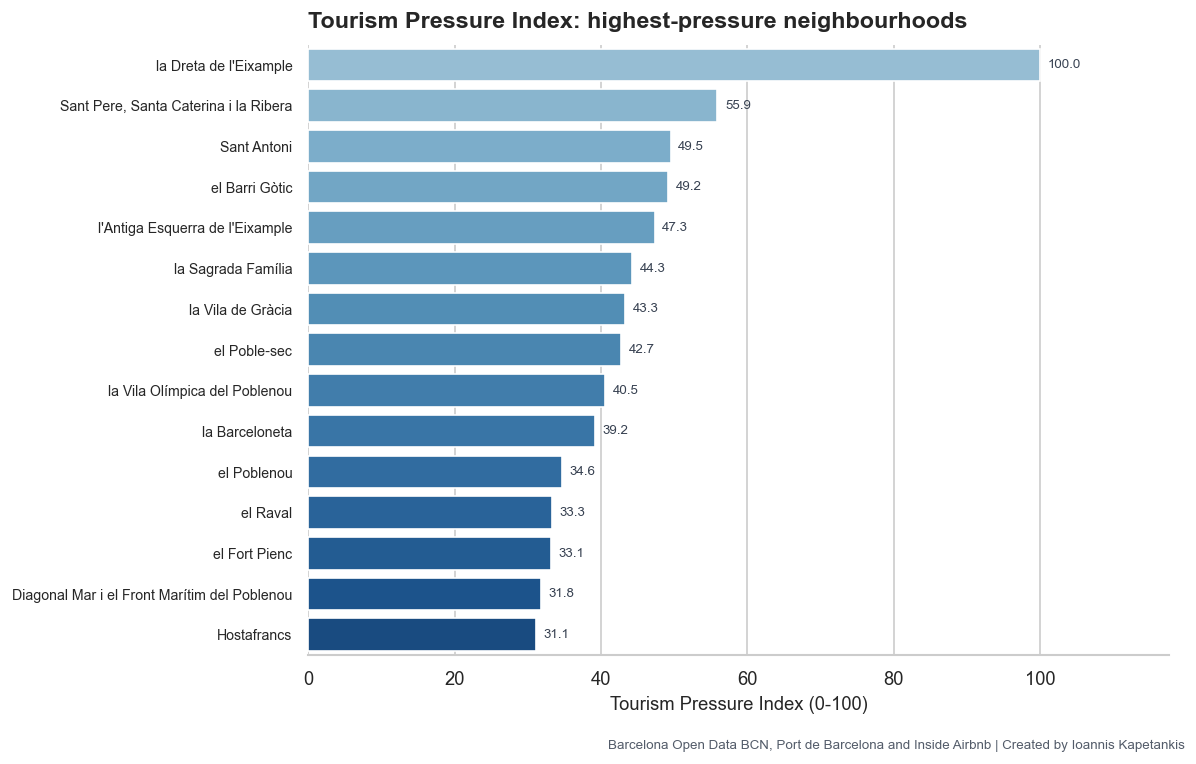

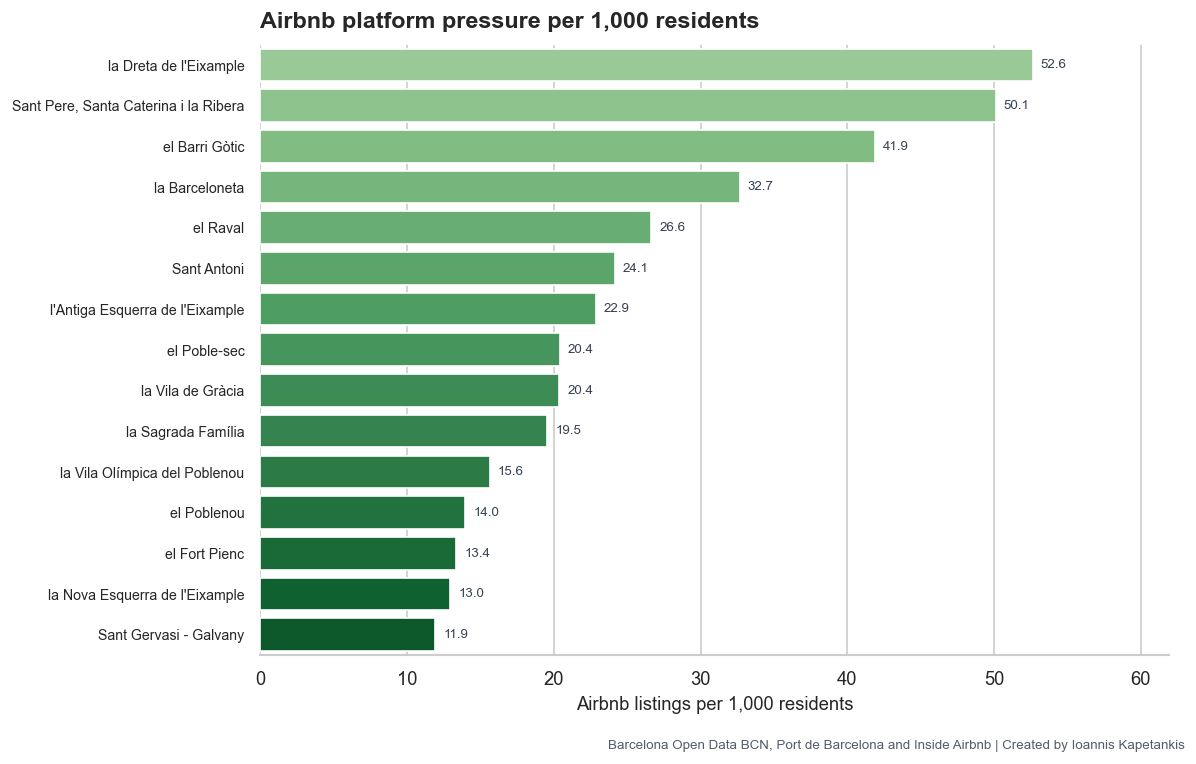

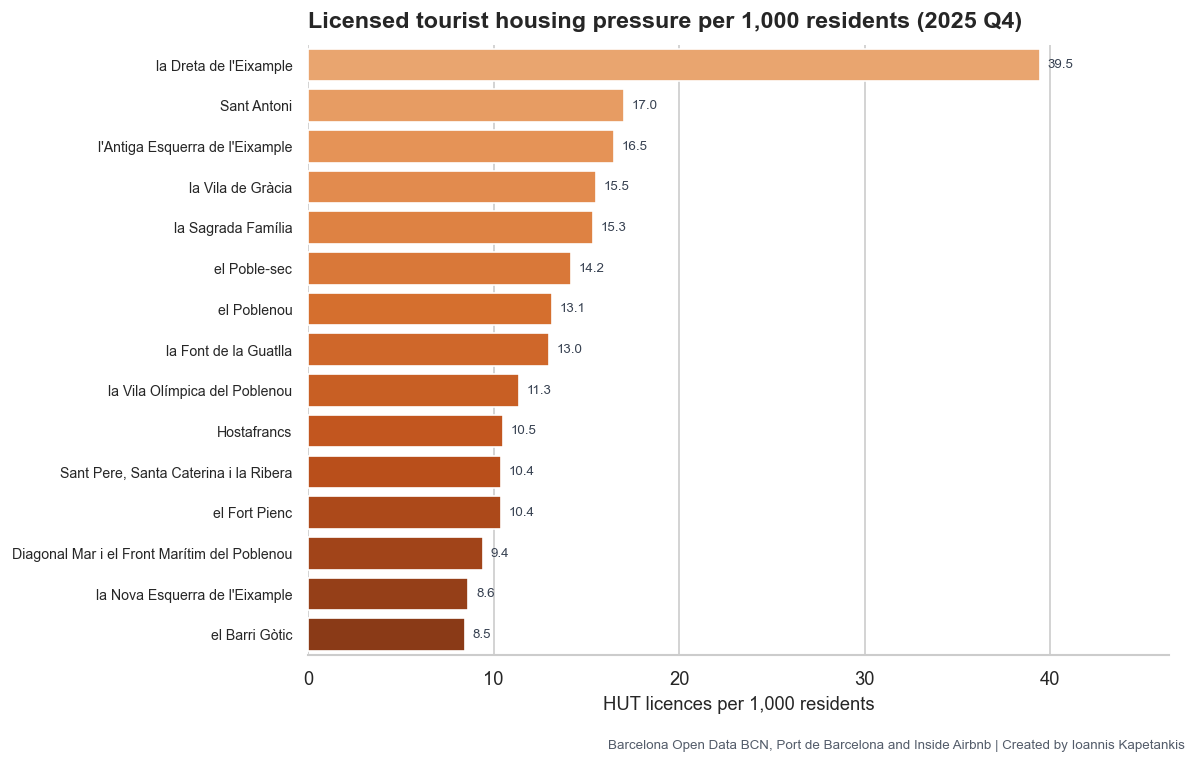

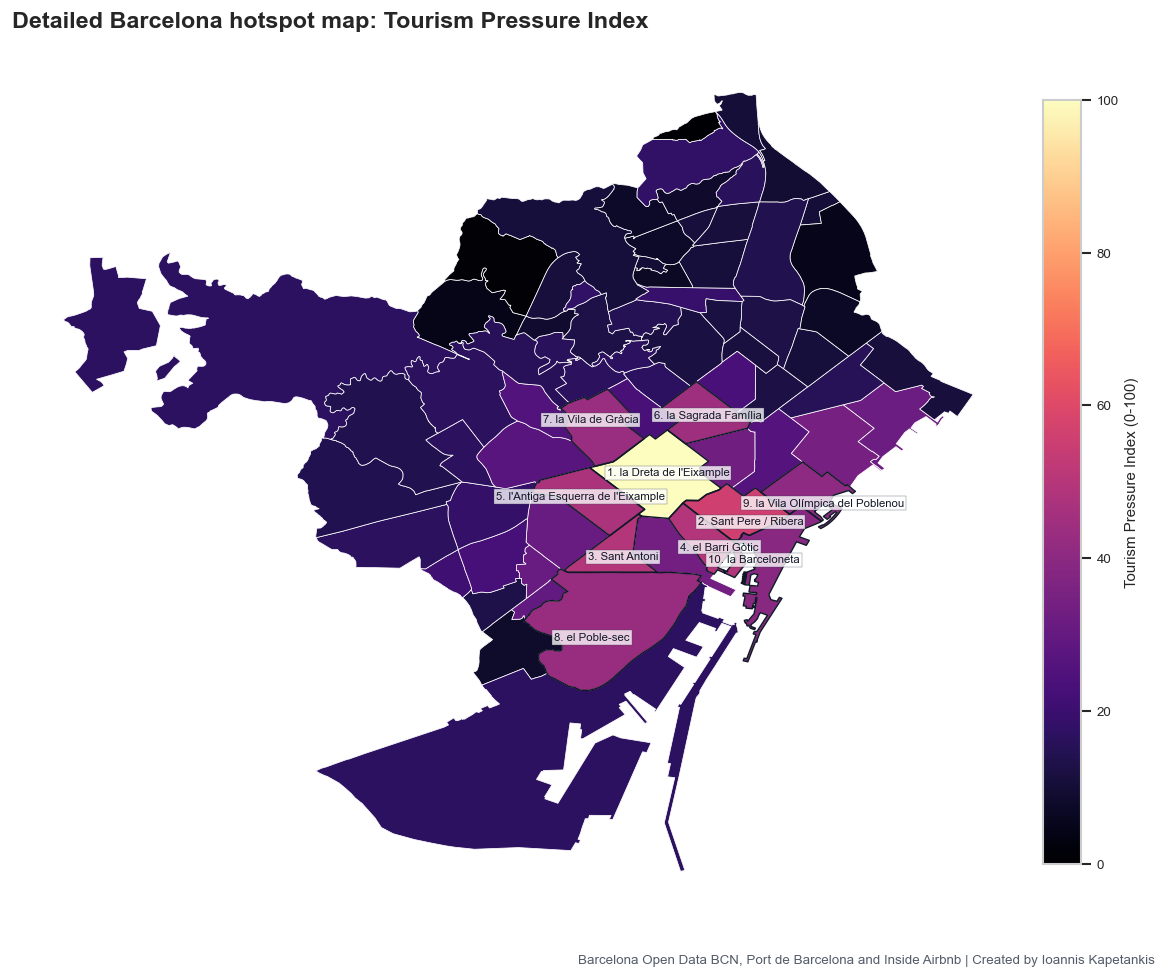

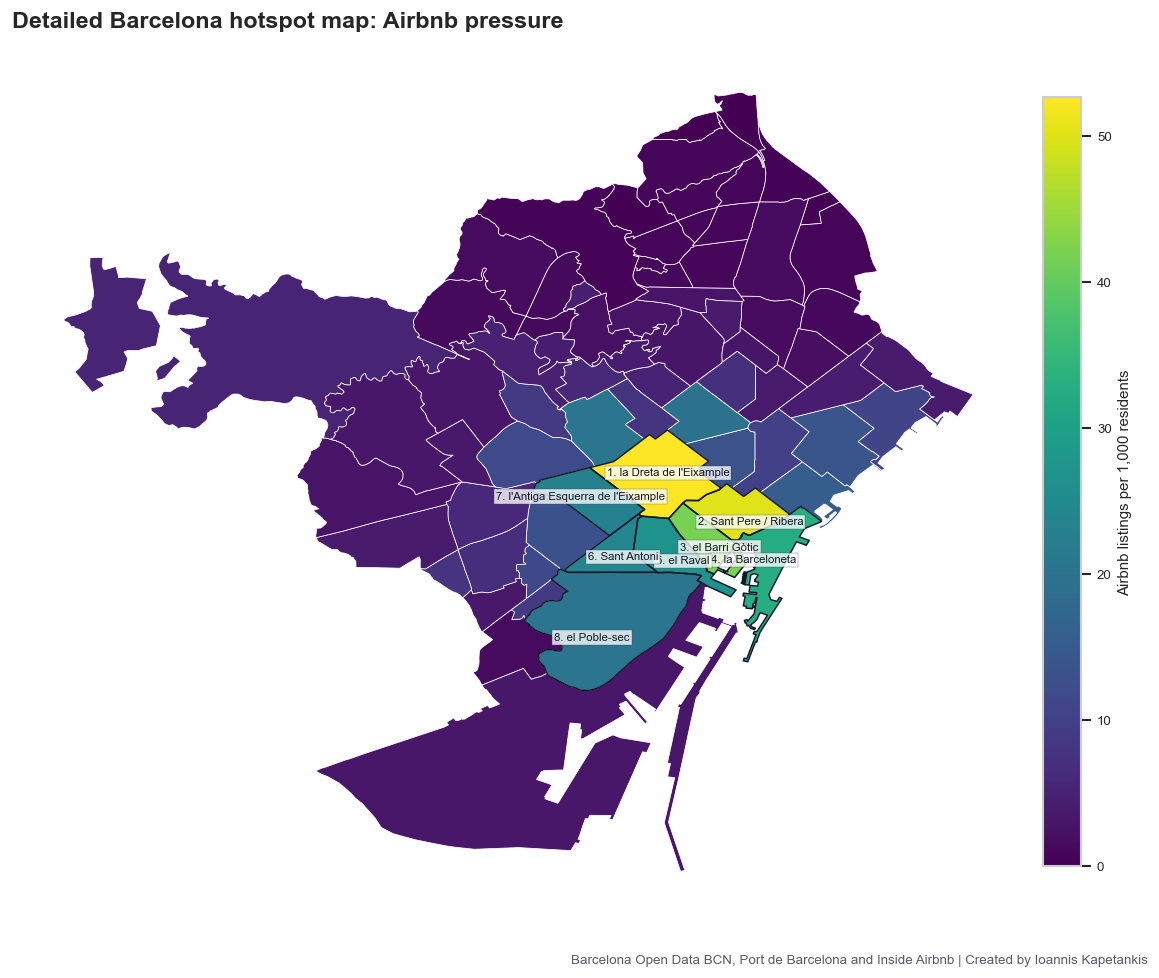

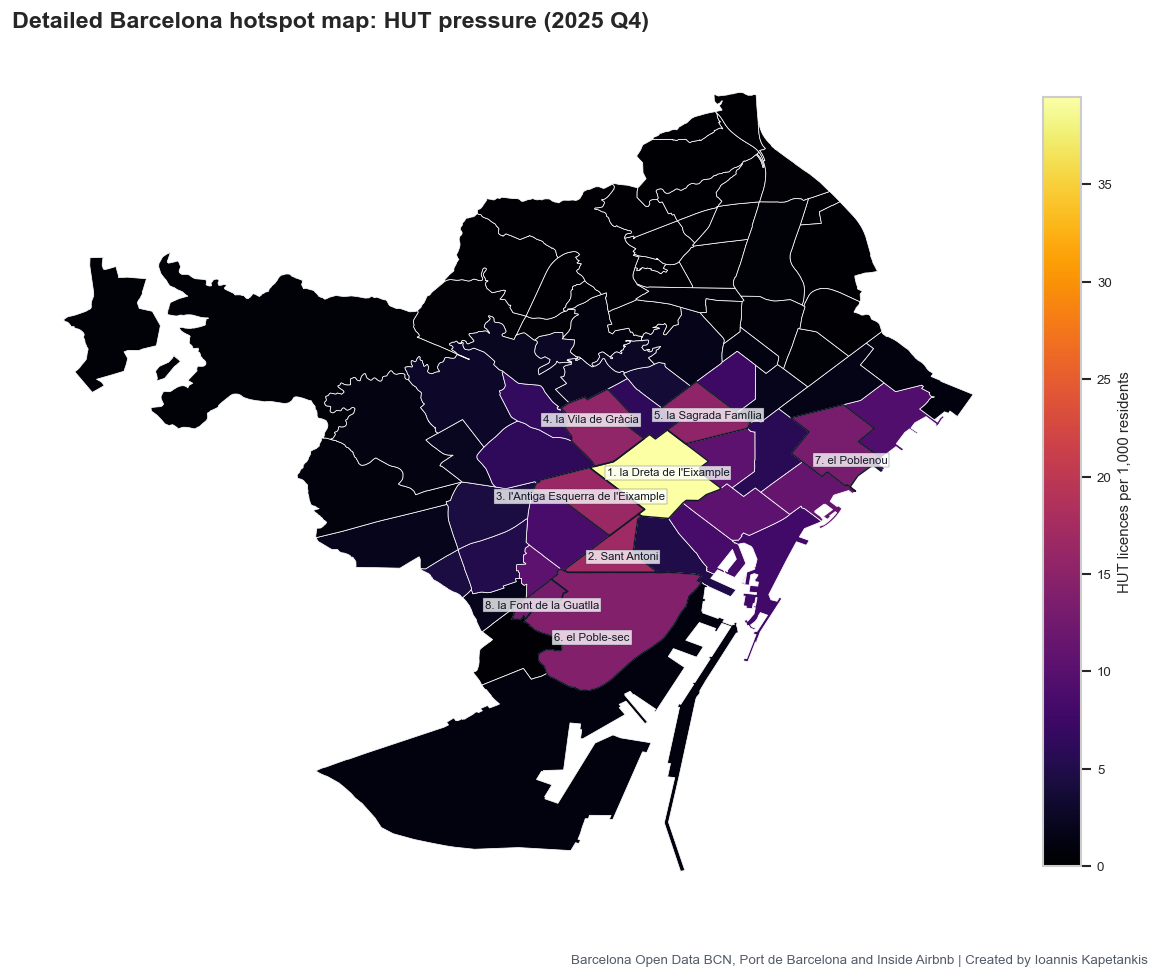

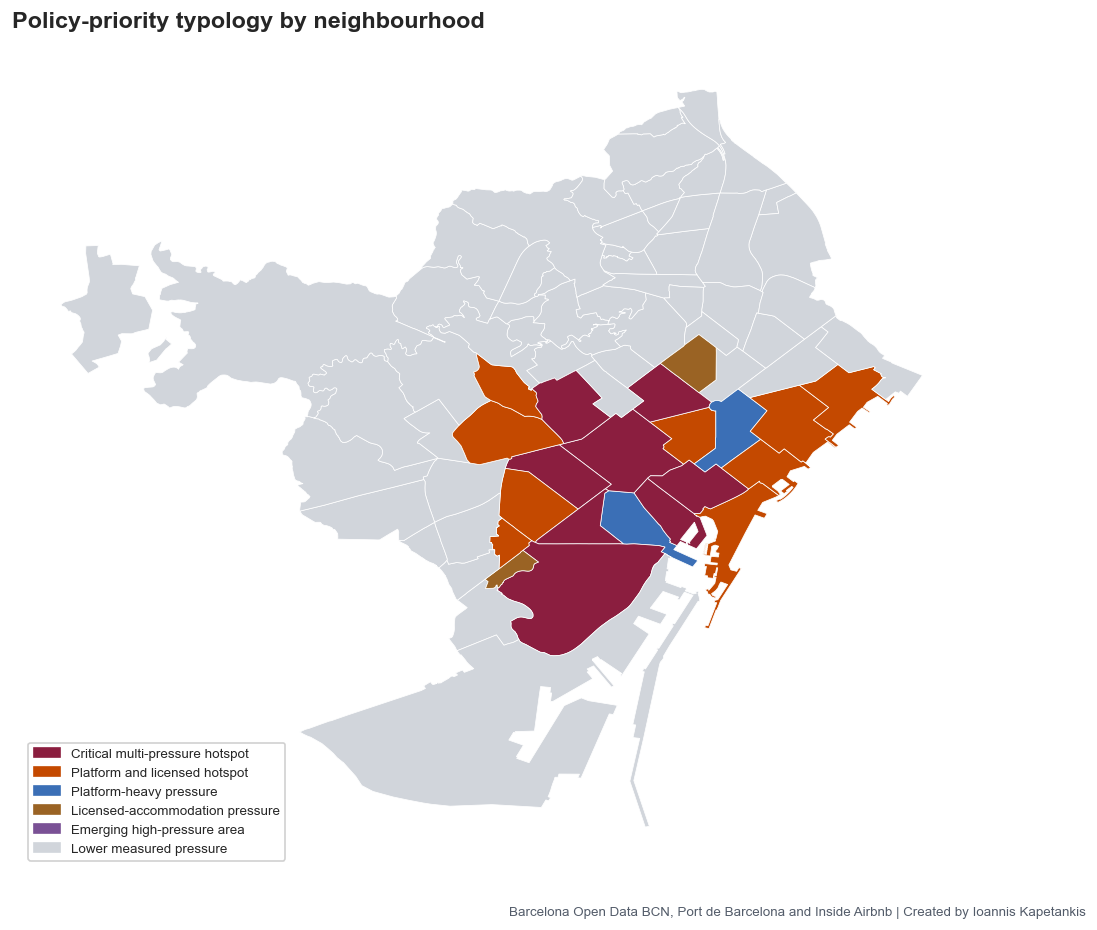

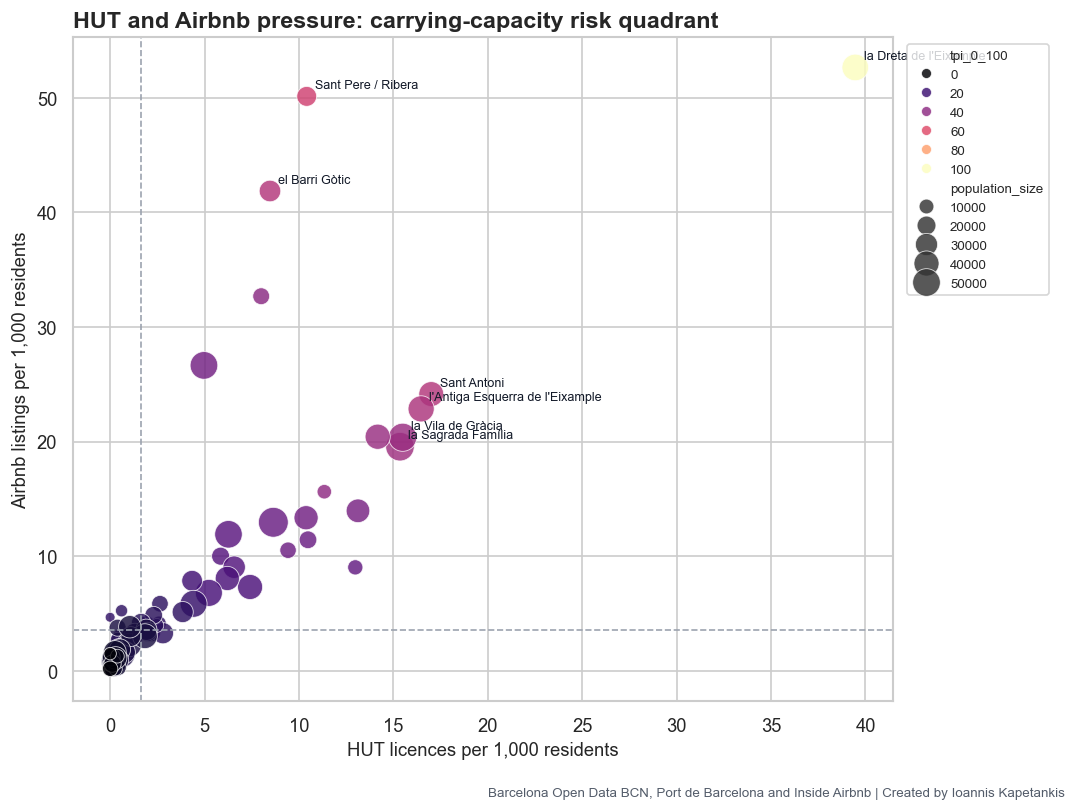

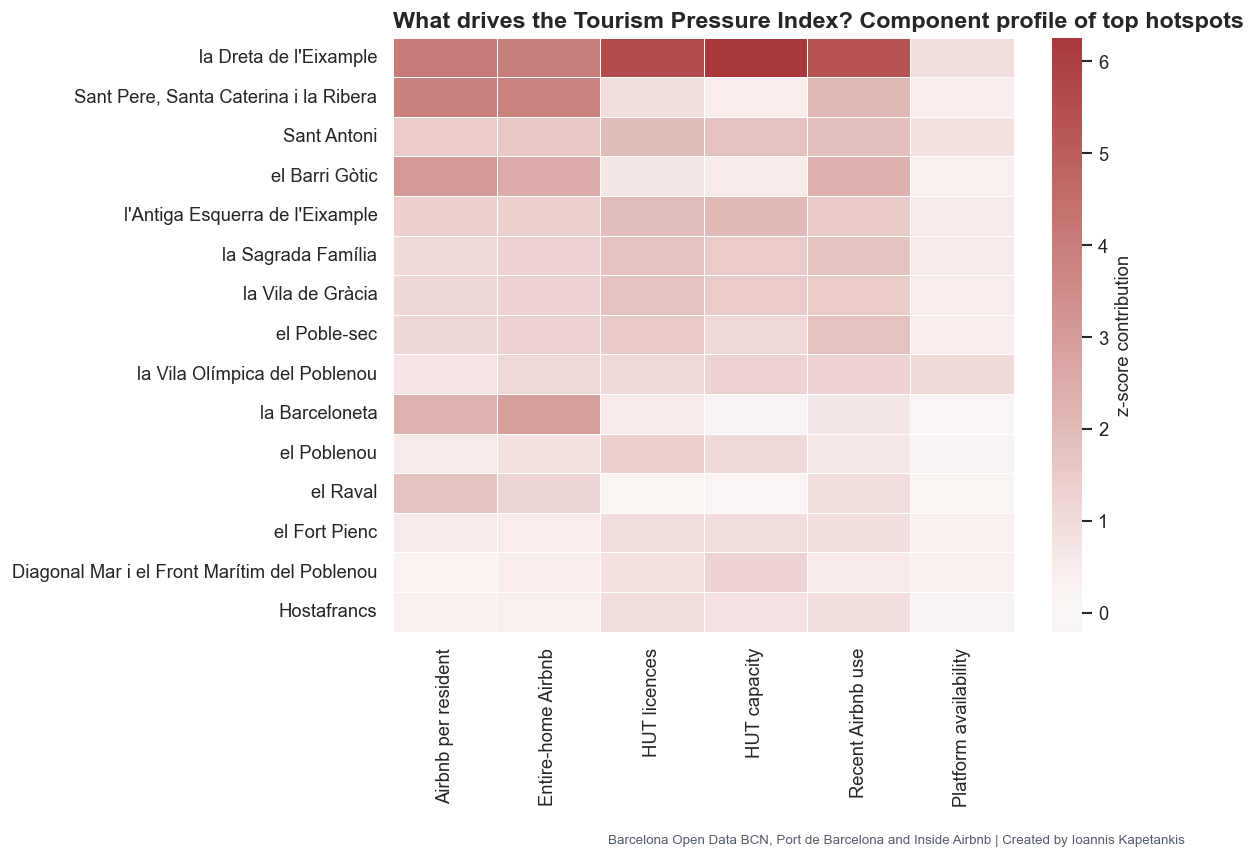

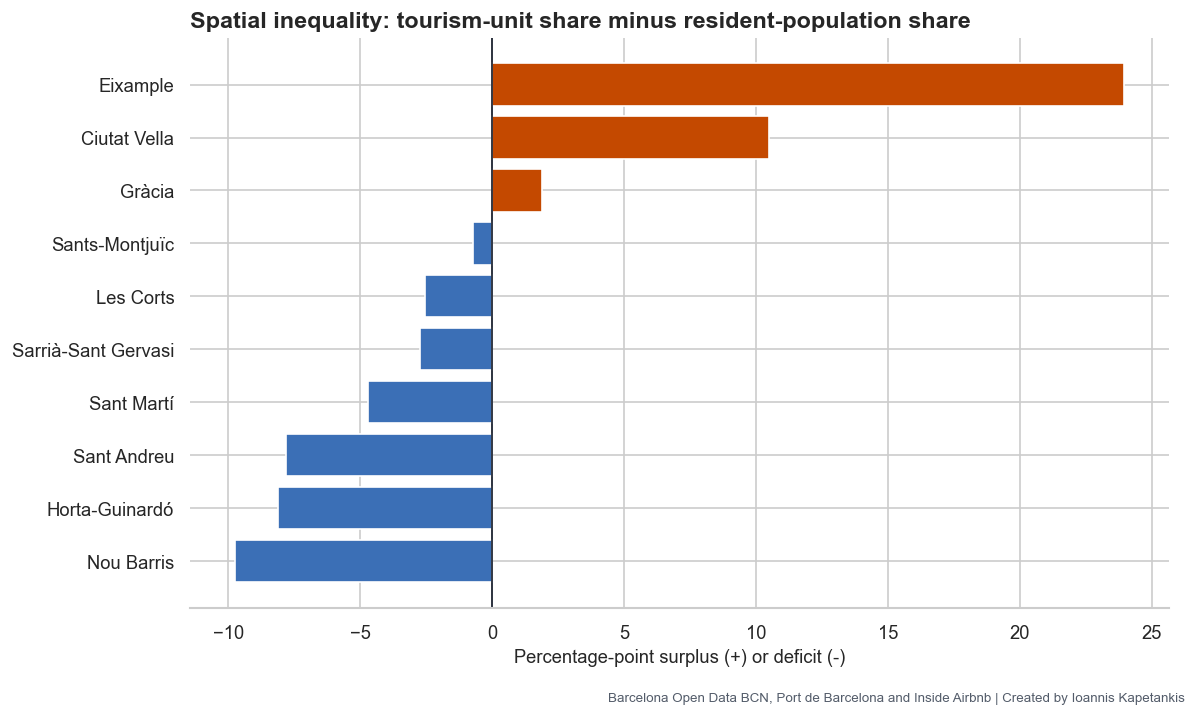

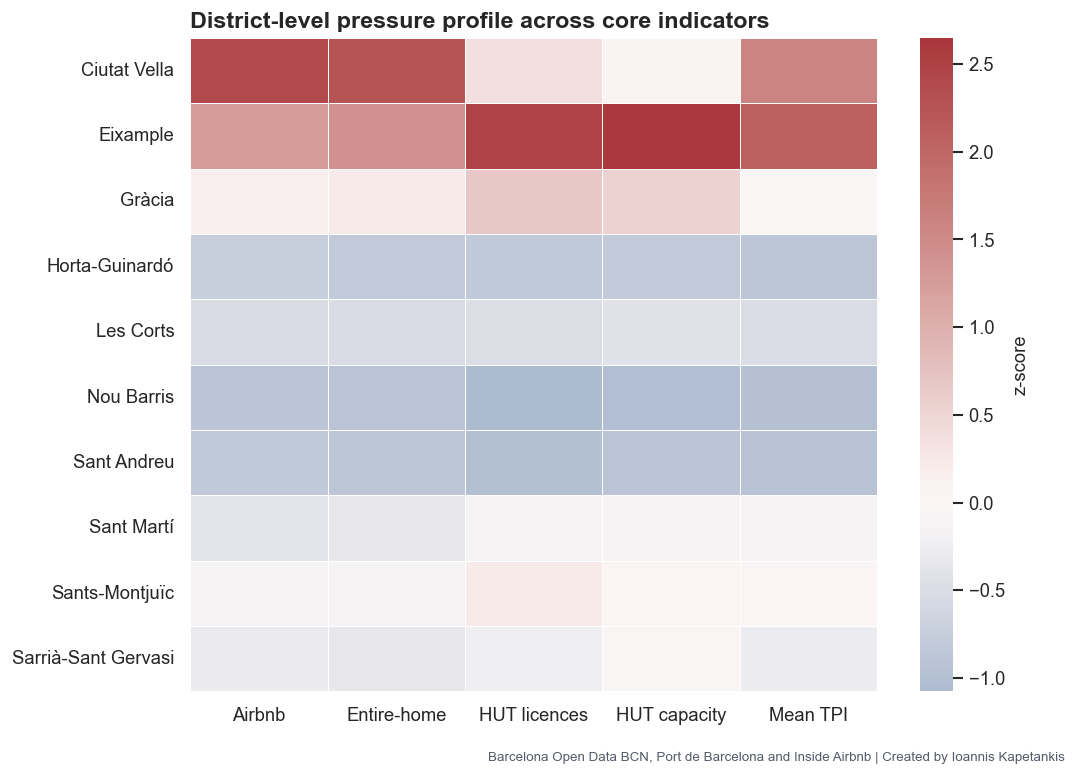

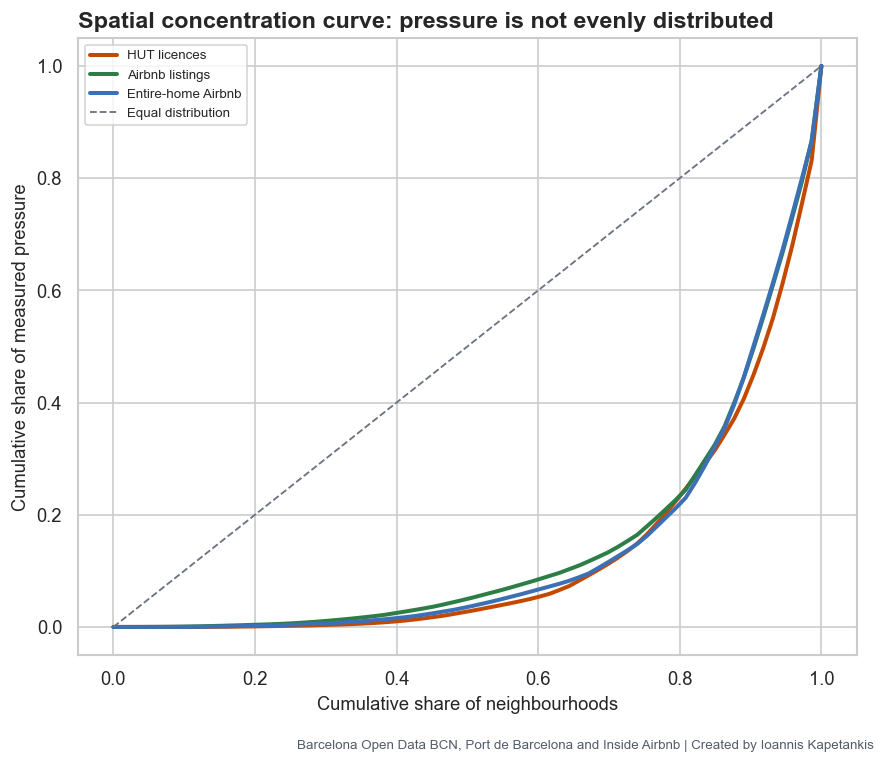

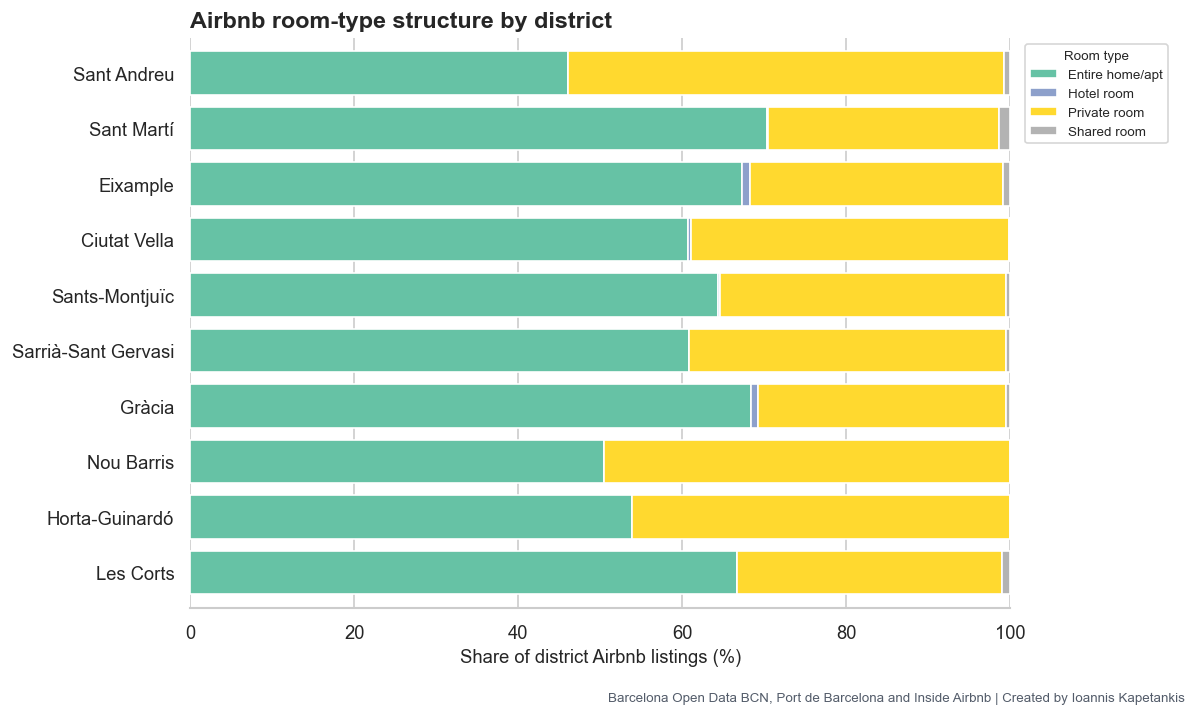

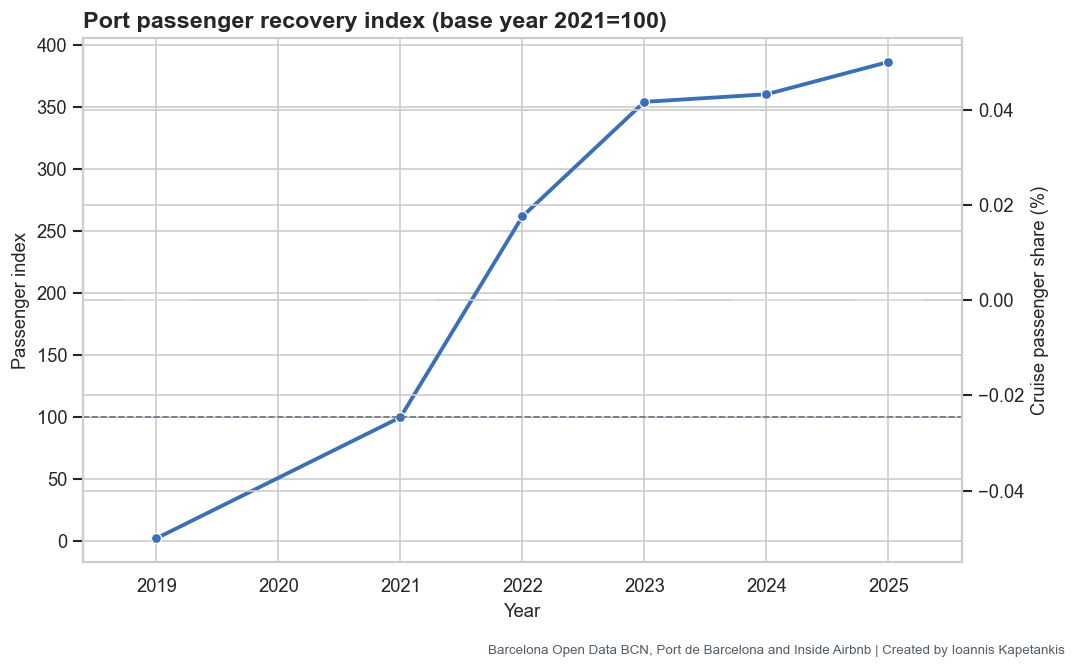

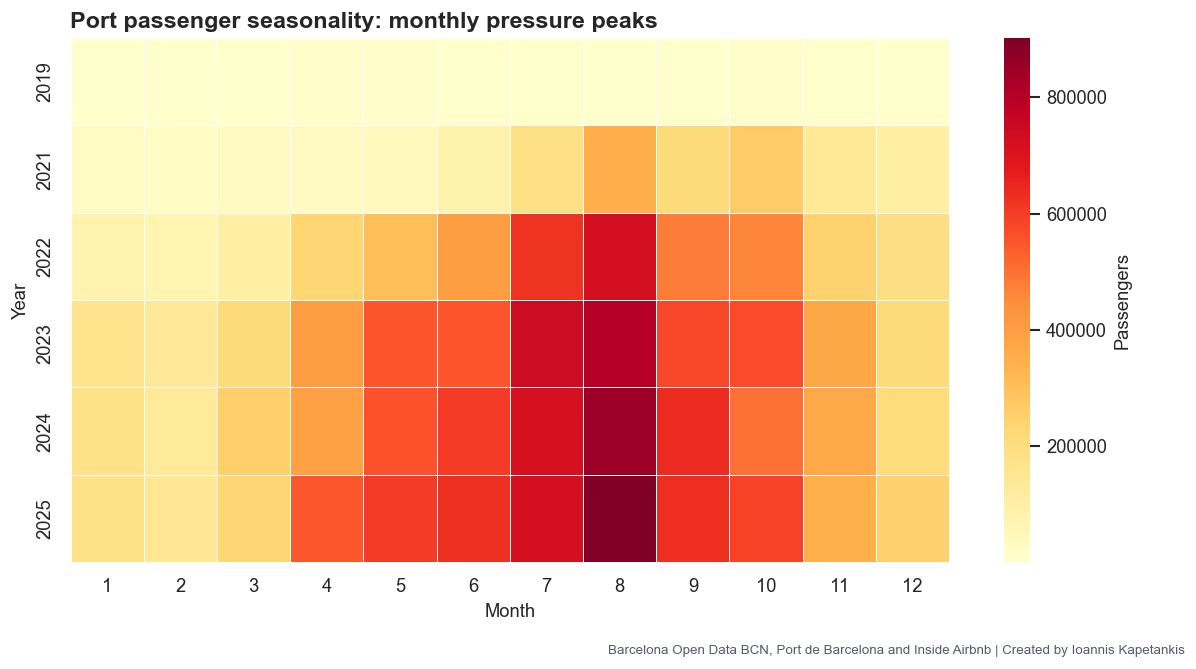

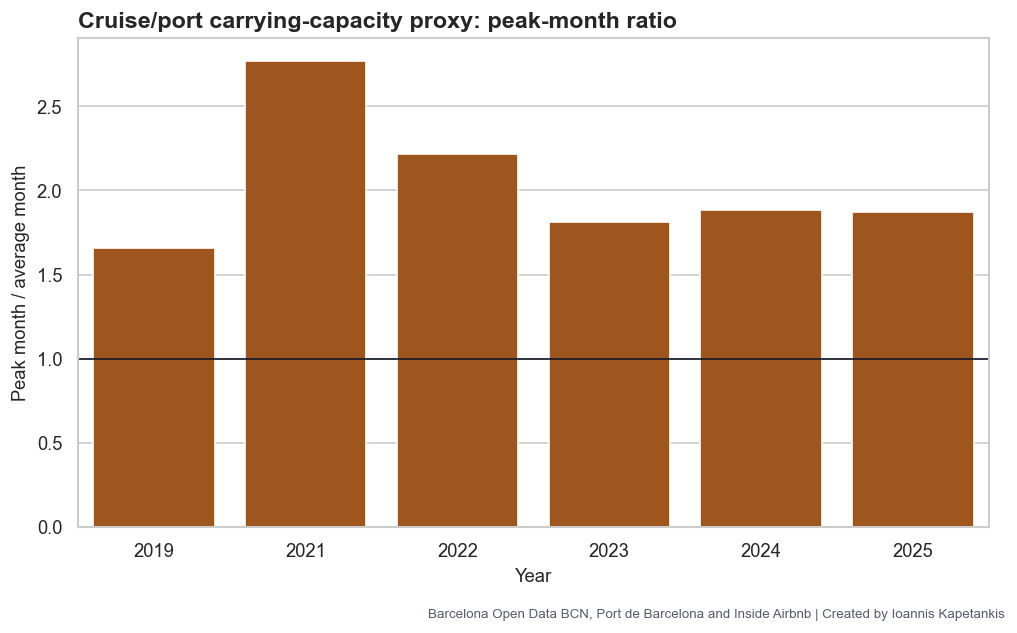

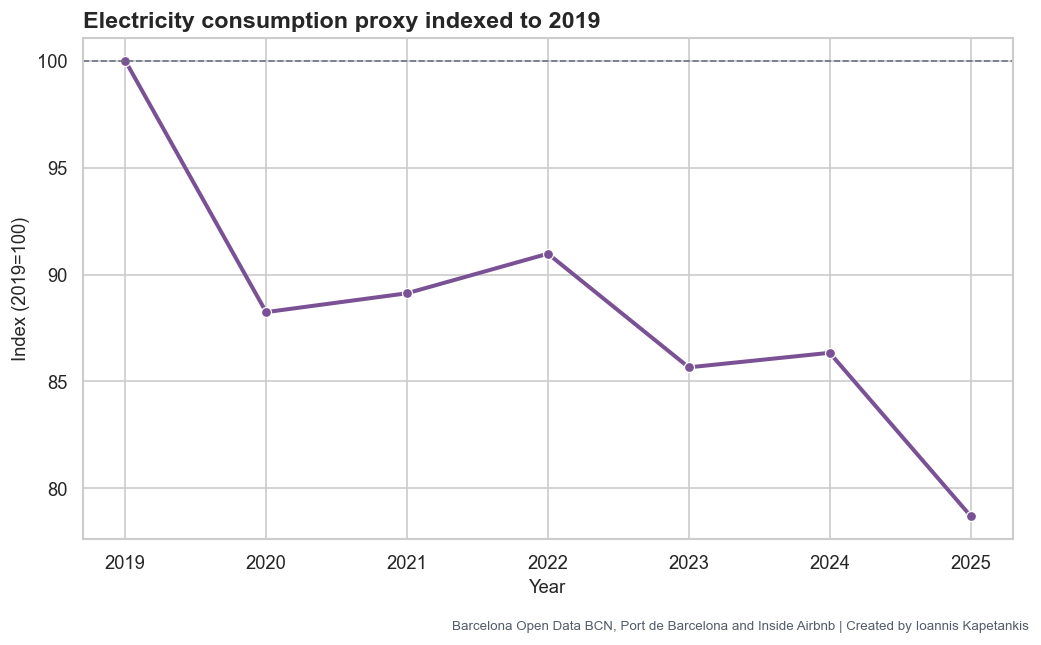

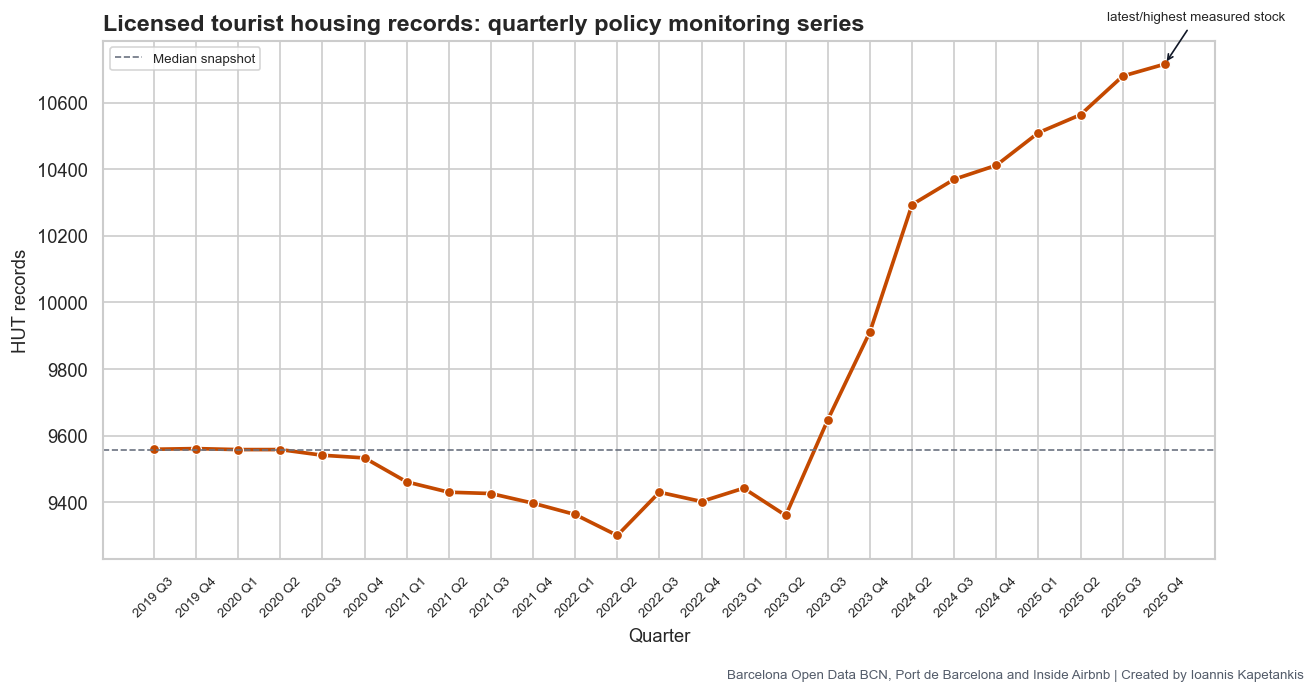

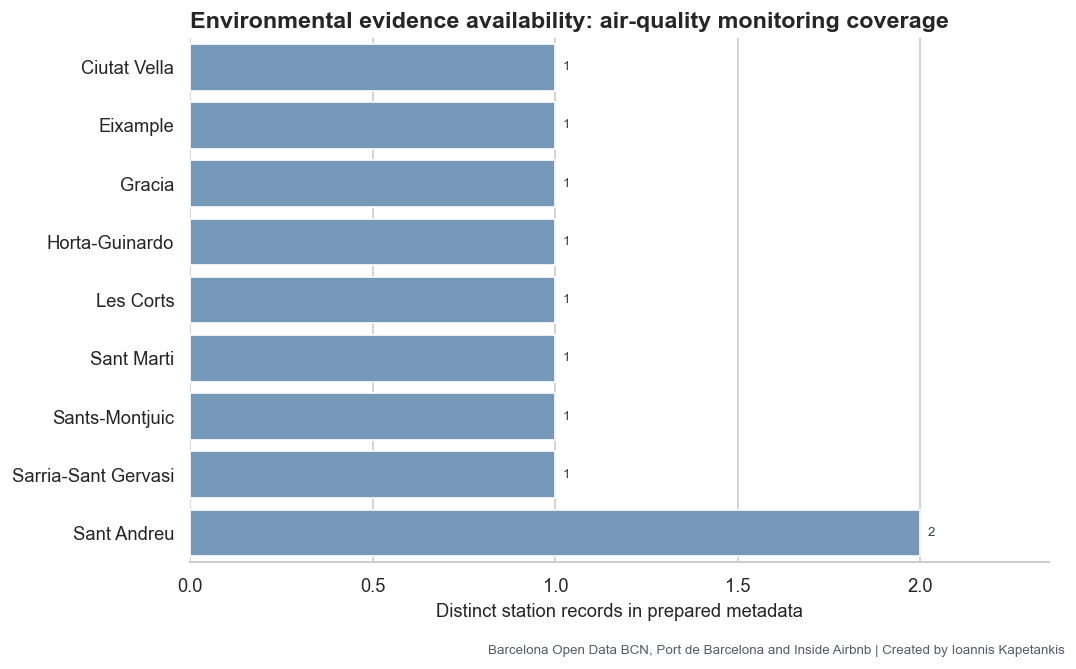

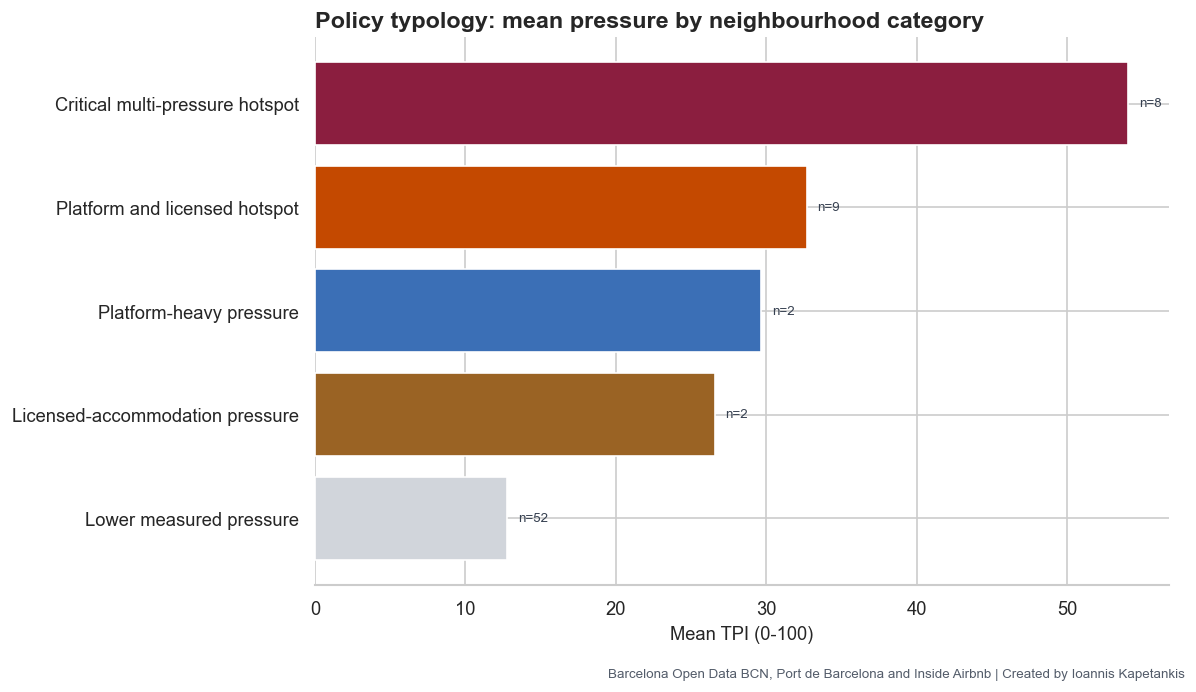

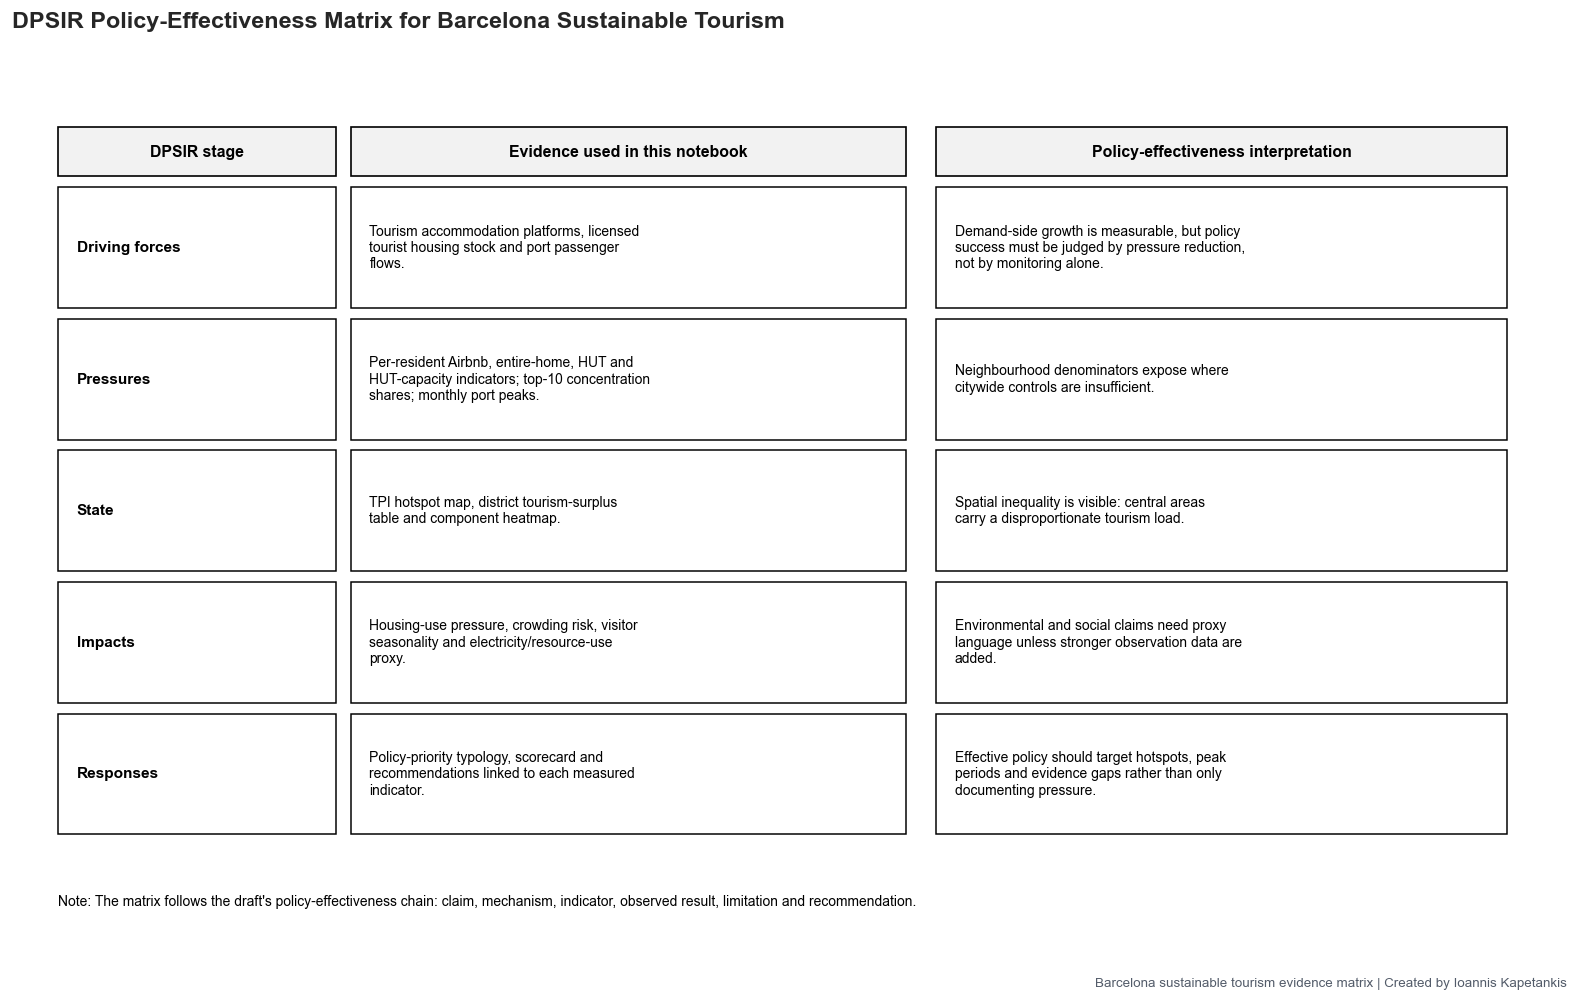

**Table 12. Enhanced generated figure files**

| figure_file                                               |
|-----------------------------------------------------------|
| outputs\figures\01_tpi_top_neighbourhoods.png             |
| outputs\figures\02_airbnb_pressure_top_neighbourhoods.png |
| outputs\figures\03_hut_pressure_top_neighbourhoods.png    |
| outputs\figures\04_tpi_choropleth.png                     |
| outputs\figures\05_airbnb_pressure_choropleth.png         |
| outputs\figures\06_hut_pressure_choropleth.png            |
| outputs\figures\07_policy_priority_typology_map.png       |
| outputs\figures\08_hut_vs_airbnb_scatter.png              |
| outputs\figures\09_tpi_component_heatmap.png              |
| outputs\figures\10_district_spatial_inequality.png        |
| outputs\figures\11_district_pressure_heatmap.png          |
| outputs\figures\12_concentration_lorenz_curve.png         |
| outputs\figures\13_airbnb_room_type_by_district.png       |
| outputs\figures\14_port_recovery_and_cruise_share.png     |
| outputs\figures\15_port_monthly_seasonality_heatmap.png   |
| outputs\figures\16_port_peak_pressure_ratio.png           |
| outputs\figures\17_electricity_consumption_index.png      |
| outputs\figures\19_hut_quarterly_trend.png                |
| outputs\figures\20_air_quality_monitoring_coverage.png    |
| outputs\figures\21_policy_priority_summary.png            |
| outputs\figures\22_dpsir_policy_effectiveness_chain.png   |

Saved 21 enhanced watermarked figures to D:\OneDrive - New York College\nyc hons hospitalty managment\semster 6\sus\Code\outputs\figures


In [39]:
saved_figures = []

AXIS_LABELS = {
    "tpi_0_100": "Tourism Pressure Index (0-100)",
    "airbnb_per_1000_residents": "Airbnb listings per 1,000 residents",
    "hut_per_1000_residents": "HUT licences per 1,000 residents",
    "tourism_units_per_1000_residents": "Tourism units per 1,000 residents",
}
PRIORITY_COLORS = {
    "Critical multi-pressure hotspot": "#8B1E3F",
    "Platform and licensed hotspot": "#C44900",
    "Platform-heavy pressure": "#3B6FB6",
    "Licensed-accommodation pressure": "#9A6324",
    "Emerging high-pressure area": "#7A5195",
    "Lower measured pressure": "#D1D5DB",
}


def save_and_show(fig, filename, source_note=FIGURE_SOURCE_NOTE):
    path = finish_figure(fig, filename, source_note=source_note)
    saved_figures.append(path)
    plt.show()
    return path


def label_series(frame):
    return frame["neighbourhood_name"].fillna(frame["neighbourhood_key"]).astype(str)


def annotate_barh(ax, decimals=1):
    xmax = ax.get_xlim()[1]
    for patch in ax.patches:
        width = patch.get_width()
        if np.isfinite(width):
            ax.text(width + xmax * 0.01, patch.get_y() + patch.get_height() / 2, f"{width:,.{decimals}f}", va="center", fontsize=8, color="#374151")
    ax.set_xlim(right=xmax * 1.12)


def horizontal_bar(frame, value_col, title, filename, cmap="Blues", n=15):
    data = frame.dropna(subset=[value_col]).head(n).copy()
    data["label"] = label_series(data)
    colors = mpl.colormaps[cmap](np.linspace(0.42, 0.90, len(data)))
    fig, ax = plt.subplots(figsize=(10, 6.4))
    sns.barplot(data=data, y="label", x=value_col, ax=ax, palette=list(colors), hue="label", legend=False)
    ax.set_title(title, loc="left", pad=10)
    ax.set_xlabel(AXIS_LABELS.get(value_col, value_col.replace("_", " ").title()))
    ax.set_ylabel("")
    ax.tick_params(axis="y", labelsize=8.5)
    annotate_barh(ax, decimals=1)
    sns.despine(ax=ax, left=True)
    save_and_show(fig, filename)


def polygon_centroid(points):
    points = np.asarray(points, dtype=float)
    return float(points[:, 0].mean()), float(points[:, 1].mean())


def draw_value_map(ax, geojson_obj, data, key_col, value_col, cmap="magma", label_top=0, highlight_top=0):
    records = polygon_records_from_geojson(geojson_obj)
    data_lookup = data.set_index(key_col)[value_col].to_dict()
    values = np.array([data_lookup.get(record["key"], np.nan) for record in records], dtype=float)
    valid_values = values[np.isfinite(values)]
    if valid_values.size == 0:
        ax.text(0.5, 0.5, "No map values available", ha="center", va="center")
        ax.axis("off")
        return None, records
    norm = mpl.colors.Normalize(vmin=float(valid_values.min()), vmax=float(valid_values.max()))
    palette = mpl.colormaps[cmap]
    patches = [MplPolygon(record["polygon"], closed=True) for record in records]
    colors = ["#F3F4F6" if not np.isfinite(value) else palette(norm(value)) for value in values]
    ax.add_collection(PatchCollection(patches, facecolor=colors, edgecolor="#FFFFFF", linewidth=0.45))
    top_keys = list(data.sort_values(value_col, ascending=False)[key_col].dropna().head(highlight_top)) if highlight_top else []
    if top_keys:
        outline = [MplPolygon(record["polygon"], closed=True) for record in records if record["key"] in set(top_keys)]
        ax.add_collection(PatchCollection(outline, facecolor="none", edgecolor="#111827", linewidth=0.9))
    all_points = np.vstack([record["polygon"] for record in records])
    ax.set_xlim(all_points[:, 0].min() - 0.01, all_points[:, 0].max() + 0.01)
    ax.set_ylim(all_points[:, 1].min() - 0.01, all_points[:, 1].max() + 0.01)
    ax.set_aspect("equal")
    ax.axis("off")
    if label_top:
        centroids = {record["key"]: polygon_centroid(record["polygon"]) for record in records}
        top_rows = data.sort_values(value_col, ascending=False).dropna(subset=[key_col]).head(label_top).reset_index(drop=True)
        for rank, row in top_rows.iterrows():
            point = centroids.get(row[key_col])
            if point is None:
                continue
            short_label = str(row.get("neighbourhood_name", row[key_col])).replace("Sant Pere, Santa Caterina i la Ribera", "Sant Pere / Ribera")
            ax.text(point[0], point[1], f"{rank + 1}. {short_label}", ha="center", va="center", fontsize=6.8, color="#111827", bbox={"facecolor": "white", "edgecolor": "#374151", "linewidth": 0.25, "alpha": 0.78, "pad": 1.2})
    return mpl.cm.ScalarMappable(norm=norm, cmap=palette), records


def detailed_hotspot_map(data, value_col, title, filename, cmap="magma", label_top=10):
    fig, ax = plt.subplots(figsize=(10.8, 8.2))
    scalar, records = draw_value_map(ax, neighbourhood_geojson, data, "neighbourhood_key", value_col, cmap=cmap, label_top=label_top, highlight_top=label_top)
    ax.set_title(title, loc="left", pad=8)
    if scalar is not None:
        cbar = fig.colorbar(scalar, ax=ax, fraction=0.032, pad=0.015)
        cbar.ax.tick_params(labelsize=8)
        cbar.set_label(AXIS_LABELS.get(value_col, value_col.replace("_", " ").title()), fontsize=9)
    save_and_show(fig, filename)


def category_map(data, category_col, title, filename):
    records = polygon_records_from_geojson(neighbourhood_geojson)
    category_lookup = data.set_index("neighbourhood_key")[category_col].to_dict()
    patches = [MplPolygon(record["polygon"], closed=True) for record in records]
    colors = [PRIORITY_COLORS.get(category_lookup.get(record["key"], "Lower measured pressure"), "#E5E7EB") for record in records]
    fig, ax = plt.subplots(figsize=(10, 7.8))
    ax.add_collection(PatchCollection(patches, facecolor=colors, edgecolor="#FFFFFF", linewidth=0.45))
    all_points = np.vstack([record["polygon"] for record in records])
    ax.set_xlim(all_points[:, 0].min() - 0.01, all_points[:, 0].max() + 0.01)
    ax.set_ylim(all_points[:, 1].min() - 0.01, all_points[:, 1].max() + 0.01)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title, loc="left", pad=8)
    handles = [mpl.patches.Patch(color=color, label=label) for label, color in PRIORITY_COLORS.items()]
    ax.legend(handles=handles, loc="lower left", bbox_to_anchor=(0.01, 0.01), fontsize=8, frameon=True, framealpha=0.9)
    save_and_show(fig, filename)


# 1-3. Improved ranking charts.
horizontal_bar(pressure.sort_values("tpi_0_100", ascending=False), "tpi_0_100", "Tourism Pressure Index: highest-pressure neighbourhoods", "01_tpi_top_neighbourhoods.png", cmap="Blues")
horizontal_bar(pressure.sort_values("airbnb_per_1000_residents", ascending=False), "airbnb_per_1000_residents", "Airbnb platform pressure per 1,000 residents", "02_airbnb_pressure_top_neighbourhoods.png", cmap="Greens")
horizontal_bar(pressure.sort_values("hut_per_1000_residents", ascending=False), "hut_per_1000_residents", f"Licensed tourist housing pressure per 1,000 residents ({hut_latest_quarter})", "03_hut_pressure_top_neighbourhoods.png", cmap="Oranges")

# 4-7. Detailed maps with labels, highlighted hotspots and central inset.
detailed_hotspot_map(pressure, "tpi_0_100", "Detailed Barcelona hotspot map: Tourism Pressure Index", "04_tpi_choropleth.png", cmap="magma", label_top=10)
detailed_hotspot_map(pressure, "airbnb_per_1000_residents", "Detailed Barcelona hotspot map: Airbnb pressure", "05_airbnb_pressure_choropleth.png", cmap="viridis", label_top=8)
detailed_hotspot_map(pressure, "hut_per_1000_residents", f"Detailed Barcelona hotspot map: HUT pressure ({hut_latest_quarter})", "06_hut_pressure_choropleth.png", cmap="inferno", label_top=8)
category_map(pressure, "policy_priority", "Policy-priority typology by neighbourhood", "07_policy_priority_typology_map.png")

# 8. HUT versus Airbnb scatter, annotated for core hotspots.
scatter_data = pressure.dropna(subset=["hut_per_1000_residents", "airbnb_per_1000_residents"]).copy()
scatter_data["population_size"] = pd.to_numeric(scatter_data["population"], errors="coerce").fillna(scatter_data["population"].median()).astype(float)
scatter_data["tpi_0_100"] = pd.to_numeric(scatter_data["tpi_0_100"], errors="coerce").astype(float)
fig, ax = plt.subplots(figsize=(9, 6.8))
sns.scatterplot(data=scatter_data, x="hut_per_1000_residents", y="airbnb_per_1000_residents", size="population_size", sizes=(35, 320), hue="tpi_0_100", palette="magma", alpha=0.82, edgecolor="white", linewidth=0.5, ax=ax)
for _, row in scatter_data.sort_values("tpi_0_100", ascending=False).head(7).iterrows():
    ax.annotate(str(row["neighbourhood_name"]).replace("Sant Pere, Santa Caterina i la Ribera", "Sant Pere / Ribera"), (row["hut_per_1000_residents"], row["airbnb_per_1000_residents"]), xytext=(5, 5), textcoords="offset points", fontsize=7.5, color="#111827")
ax.axvline(scatter_data["hut_per_1000_residents"].median(), color="#9CA3AF", linestyle="--", linewidth=1)
ax.axhline(scatter_data["airbnb_per_1000_residents"].median(), color="#9CA3AF", linestyle="--", linewidth=1)
ax.set_title("HUT and Airbnb pressure: carrying-capacity risk quadrant", loc="left")
ax.set_xlabel("HUT licences per 1,000 residents")
ax.set_ylabel("Airbnb listings per 1,000 residents")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8, title_fontsize=8)
save_and_show(fig, "08_hut_vs_airbnb_scatter.png")

# 9. TPI component heatmap.
component_heatmap = tpi_component_profile.set_index("neighbourhood_name").drop(columns=["district_name", "tpi_0_100"]).head(15)
fig, ax = plt.subplots(figsize=(10, 7.2))
sns.heatmap(component_heatmap, cmap="vlag", center=0, linewidths=0.4, ax=ax, cbar_kws={"label": "z-score contribution"})
ax.set_title("What drives the Tourism Pressure Index? Component profile of top hotspots", loc="left")
ax.set_xlabel("")
ax.set_ylabel("")
save_and_show(fig, "09_tpi_component_heatmap.png")

# 10. District spatial inequality.
fig, ax = plt.subplots(figsize=(10, 6))
ineq_plot = district_inequality.sort_values("tourism_surplus_vs_population_pct_points", ascending=True)
colors = np.where(ineq_plot["tourism_surplus_vs_population_pct_points"] >= 0, "#C44900", "#3B6FB6")
ax.barh(ineq_plot["district_name"], ineq_plot["tourism_surplus_vs_population_pct_points"], color=colors)
ax.axvline(0, color="#111827", linewidth=1)
ax.set_title("Spatial inequality: tourism-unit share minus resident-population share", loc="left")
ax.set_xlabel("Percentage-point surplus (+) or deficit (-)")
ax.set_ylabel("")
sns.despine(ax=ax, left=True)
save_and_show(fig, "10_district_spatial_inequality.png")

# 11. District comparison heatmap.
heatmap_cols = ["airbnb_per_1000_residents", "entire_home_airbnb_per_1000_residents", "hut_per_1000_residents", "hut_places_per_1000_residents", "mean_tpi_0_100"]
heatmap_labels = ["Airbnb", "Entire-home", "HUT licences", "HUT capacity", "Mean TPI"]
heatmap_data = district_pressure.set_index("district_name")[heatmap_cols].apply(zscore).fillna(0)
heatmap_data.columns = heatmap_labels
fig, ax = plt.subplots(figsize=(9, 6.5))
sns.heatmap(heatmap_data, cmap="vlag", center=0, linewidths=0.4, ax=ax, cbar_kws={"label": "z-score"})
ax.set_title("District-level pressure profile across core indicators", loc="left")
ax.set_xlabel("")
ax.set_ylabel("")
save_and_show(fig, "11_district_pressure_heatmap.png")

# 12. Lorenz/concentration curves.
fig, ax = plt.subplots(figsize=(7.4, 6.4))
for value_col, label, color in [("hut_licenses", "HUT licences", "#C44900"), ("listings", "Airbnb listings", "#2D7D46"), ("entire_home_listings", "Entire-home Airbnb", "#3B6FB6")]:
    values = np.sort(pd.to_numeric(pressure[value_col], errors="coerce").fillna(0).to_numpy())
    cumulative = np.insert(np.cumsum(values), 0, 0)
    cumulative = cumulative / cumulative[-1] if cumulative[-1] else cumulative
    neighbourhood_share = np.linspace(0, 1, len(cumulative))
    ax.plot(neighbourhood_share, cumulative, label=label, linewidth=2.4, color=color)
ax.plot([0, 1], [0, 1], color="#6B7280", linestyle="--", linewidth=1.1, label="Equal distribution")
ax.set_title("Spatial concentration curve: pressure is not evenly distributed", loc="left")
ax.set_xlabel("Cumulative share of neighbourhoods")
ax.set_ylabel("Cumulative share of measured pressure")
ax.legend(fontsize=8)
save_and_show(fig, "12_concentration_lorenz_curve.png")

# 13. Airbnb accommodation structure by district.
room_pivot = room_type_district.pivot_table(index="district_name", columns="room_type_clean", values="share_pct", aggfunc="sum").fillna(0)
room_pivot = room_pivot.loc[room_pivot.sum(axis=1).sort_values(ascending=True).index]
fig, ax = plt.subplots(figsize=(10, 6))
room_pivot.plot(kind="barh", stacked=True, ax=ax, colormap="Set2", width=0.78)
ax.set_title("Airbnb room-type structure by district", loc="left")
ax.set_xlabel("Share of district Airbnb listings (%)")
ax.set_ylabel("")
ax.legend(title="Room type", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, title_fontsize=8)
sns.despine(ax=ax, left=True)
save_and_show(fig, "13_airbnb_room_type_by_district.png")

# 14. Port recovery and cruise share.
fig, ax1 = plt.subplots(figsize=(9, 5.6))
sns.lineplot(data=port_recovery, x="year", y="passenger_index", marker="o", ax=ax1, color="#3B6FB6", linewidth=2.3)
ax1.axhline(100, color="#6B7280", linestyle="--", linewidth=1)
ax1.set_title(f"Port passenger recovery index (base year {port_base_year}=100)", loc="left")
ax1.set_xlabel("Year")
ax1.set_ylabel("Passenger index")
ax2 = ax1.twinx()
ax2.bar(port_recovery["year"], port_recovery["cruise_share_pct"], color="#F59E0B", alpha=0.28, width=0.55)
ax2.set_ylabel("Cruise passenger share (%)")
save_and_show(fig, "14_port_recovery_and_cruise_share.png")

# 15. Port monthly seasonality heatmap.
fig, ax = plt.subplots(figsize=(10, 5.6))
sns.heatmap(port_month_matrix, cmap="YlOrRd", linewidths=0.4, ax=ax, cbar_kws={"label": "Passengers"})
ax.set_title("Port passenger seasonality: monthly pressure peaks", loc="left")
ax.set_xlabel("Month")
ax.set_ylabel("Year")
save_and_show(fig, "15_port_monthly_seasonality_heatmap.png")

# 16. Peak-to-average pressure ratio.
fig, ax = plt.subplots(figsize=(8.5, 5.3))
sns.barplot(data=port_peak.sort_values("year"), x="year", y="peak_to_average_ratio", ax=ax, color="#B45309")
ax.axhline(1, color="#111827", linewidth=1)
ax.set_title("Cruise/port carrying-capacity proxy: peak-month ratio", loc="left")
ax.set_xlabel("Year")
ax.set_ylabel("Peak month / average month")
save_and_show(fig, "16_port_peak_pressure_ratio.png")

# 17-18. Electricity proxy figures.
fig, ax = plt.subplots(figsize=(8.7, 5.4))
sns.lineplot(data=electricity_index, x="year", y="consumption_index_2019_100", marker="o", ax=ax, color="#7A5195", linewidth=2.4)
ax.axhline(100, color="#6B7280", linestyle="--", linewidth=1)
ax.set_title("Electricity consumption proxy indexed to 2019", loc="left")
ax.set_xlabel("Year")
ax.set_ylabel("Index (2019=100)")
save_and_show(fig, "17_electricity_consumption_index.png")

if not electricity_postcode_top.empty:
    fig, ax = plt.subplots(figsize=(9, 5.8))
    sns.barplot(data=electricity_postcode_top.sort_values("consumption_value", ascending=True), y="postcode", x="consumption_value", ax=ax, color="#7A5195")
    ax.set_title(f"Highest electricity consumption postcodes ({electricity_postcode_latest_year})", loc="left")
    ax.set_xlabel("Consumption value")
    ax.set_ylabel("Postcode")
    sns.despine(ax=ax, left=True)
    save_and_show(fig, "18_top_electricity_postcodes.png")

# 19. HUT quarterly trend.
fig, ax = plt.subplots(figsize=(11, 5.8))
hut_trend_plot = hut_trend.sort_values("quarter").copy()
sns.lineplot(data=hut_trend_plot, x="quarter", y="hut_license_records", marker="o", ax=ax, color="#C44900", linewidth=2.2)
ax.axhline(hut_trend_plot["hut_license_records"].median(), color="#6B7280", linestyle="--", linewidth=1, label="Median snapshot")
if not hut_trend_plot.empty:
    high_row = hut_trend_plot.loc[hut_trend_plot["hut_license_records"].idxmax()]
    ax.annotate("latest/highest measured stock", xy=(high_row["quarter"], high_row["hut_license_records"]), xytext=(-35, 26), textcoords="offset points", arrowprops={"arrowstyle": "->", "color": "#111827"}, fontsize=8)
ax.set_title("Licensed tourist housing records: quarterly policy monitoring series", loc="left")
ax.set_xlabel("Quarter")
ax.set_ylabel("HUT records")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.legend(fontsize=8)
save_and_show(fig, "19_hut_quarterly_trend.png")

# 20. Air-quality monitoring coverage.
fig, ax = plt.subplots(figsize=(9, 5.6))
if not air_quality_coverage.empty:
    coverage_plot = air_quality_coverage.sort_values("station_records", ascending=True)
    sns.barplot(data=coverage_plot, y="district_name", x="station_records", ax=ax, color="#6B9AC4")
    annotate_barh(ax, decimals=0)
ax.set_title("Environmental evidence availability: air-quality monitoring coverage", loc="left")
ax.set_xlabel("Distinct station records in prepared metadata")
ax.set_ylabel("")
sns.despine(ax=ax, left=True)
save_and_show(fig, "20_air_quality_monitoring_coverage.png")

# 21. Priority typology summary.
fig, ax = plt.subplots(figsize=(10, 5.8))
priority_plot = priority_counts.sort_values("mean_tpi", ascending=True)
bar_colors = [PRIORITY_COLORS.get(label, "#9CA3AF") for label in priority_plot["policy_priority"]]
ax.barh(priority_plot["policy_priority"], priority_plot["mean_tpi"], color=bar_colors)
ax.set_title("Policy typology: mean pressure by neighbourhood category", loc="left")
ax.set_xlabel("Mean TPI (0-100)")
ax.set_ylabel("")
for y_pos, (_, row) in enumerate(priority_plot.iterrows()):
    ax.text(row["mean_tpi"] + 0.7, y_pos, f"n={int(row['neighbourhoods'])}", va="center", fontsize=8, color="#374151")
sns.despine(ax=ax, left=True)
save_and_show(fig, "21_policy_priority_summary.png")

# 22. Classical black-and-white DPSIR / policy-effectiveness matrix.
import textwrap

def wrap_box_text(value, width):
    return "\n".join(textwrap.wrap(str(value), width=width, break_long_words=False))

fig, ax = plt.subplots(figsize=(13.2, 8.4))
ax.axis("off")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("DPSIR Policy-Effectiveness Matrix for Barcelona Sustainable Tourism", loc="left", pad=14, fontsize=14, weight="bold")
columns = [
    ("DPSIR stage", 0.03, 0.18),
    ("Evidence used in this notebook", 0.22, 0.36),
    ("Policy-effectiveness interpretation", 0.60, 0.37),
]
header_y = 0.86
row_height = 0.135
row_gap = 0.012
for label, x, width in columns:
    ax.add_patch(mpl.patches.Rectangle((x, header_y), width, 0.055, facecolor="#F2F2F2", edgecolor="black", linewidth=1.0))
    ax.text(x + width / 2, header_y + 0.0275, label, ha="center", va="center", fontsize=9.5, weight="bold", color="black")
classic_rows = [
    ("Driving forces", "Tourism accommodation platforms, licensed tourist housing stock and port passenger flows.", "Demand-side growth is measurable, but policy success must be judged by pressure reduction, not by monitoring alone."),
    ("Pressures", "Per-resident Airbnb, entire-home, HUT and HUT-capacity indicators; top-10 concentration shares; monthly port peaks.", "Neighbourhood denominators expose where citywide controls are insufficient."),
    ("State", "TPI hotspot map, district tourism-surplus table and component heatmap.", "Spatial inequality is visible: central areas carry a disproportionate tourism load."),
    ("Impacts", "Housing-use pressure, crowding risk, visitor seasonality and electricity/resource-use proxy.", "Environmental and social claims need proxy language unless stronger observation data are added."),
    ("Responses", "Policy-priority typology, scorecard and recommendations linked to each measured indicator.", "Effective policy should target hotspots, peak periods and evidence gaps rather than only documenting pressure."),
]
for idx, row_values in enumerate(classic_rows):
    y = header_y - (idx + 1) * (row_height + row_gap)
    for col_idx, (text_value, (_, x, width)) in enumerate(zip(row_values, columns)):
        ax.add_patch(mpl.patches.Rectangle((x, y), width, row_height, facecolor="white", edgecolor="black", linewidth=0.9))
        wrap_width = [18, 45, 46][col_idx]
        fontsize = [9.2, 8.3, 8.3][col_idx]
        weight = "bold" if col_idx == 0 else "normal"
        ax.text(x + 0.012, y + row_height / 2, wrap_box_text(text_value, wrap_width), ha="left", va="center", fontsize=fontsize, weight=weight, linespacing=1.22, color="black")
ax.text(0.03, 0.045, "Note: The matrix follows the draft's policy-effectiveness chain: claim, mechanism, indicator, observed result, limitation and recommendation.", fontsize=8.3, color="black")
save_and_show(fig, "22_dpsir_policy_effectiveness_chain.png", source_note="Barcelona sustainable tourism evidence matrix")

figures_index = pd.DataFrame({"figure_file": [str(path.relative_to(ROOT)) for path in saved_figures]})
save_table(figures_index, "generated figure index")
formal_table(figures_index, "Table 12. Enhanced generated figure files", max_rows=30)
print(f"Saved {len(saved_figures)} enhanced watermarked figures to {FIGURES_DIR}")

In [28]:
method_notes = pd.DataFrame([
    {
        "area": "Population denominators",
        "decision": f"Used Open Data BCN pad_mdbas_sexe resident population by neighbourhood, latest available year {latest_population_year}.",
    },
    {
        "area": "Spatial unit",
        "decision": "Neighbourhood is the main unit for HUT, Airbnb, population and maps; district summaries are provided as a roll-up.",
    },
    {
        "area": "Electricity",
        "decision": "Kept as postcode/citywide resource-pressure proxy because no official postcode-to-neighbourhood crosswalk is present in the prepared data.",
    },
    {
        "area": "Air quality",
        "decision": "Used station/pollutant metadata as monitoring coverage; pollutant observation time series are not in the prepared source list.",
    },
    {
        "area": "Tourism Pressure Index",
        "decision": "Built an available-data index from z-scored HUT, Airbnb, entire-home, reviews and availability components; it should be described as an indicator of measured pressure, not a causal proof of policy effectiveness.",
    },
])
save_table(method_notes, "method notes and limitations")
formal_table(method_notes, "Table 9. Method notes and limitations", max_rows=10)

summary_text = f"""
## Reproducibility Summary

- Prepared files profiled: **{len(file_inventory)}**
- Supplementary population denominator rows: **{len(population):,}**
- Latest population year: **{latest_population_year}**
- Latest HUT snapshot used for spatial pressure: **{hut_latest_quarter}**
- Formal tables exported to: `{TABLES_DIR.relative_to(ROOT)}`
- Watermarked figures exported to: `{FIGURES_DIR.relative_to(ROOT)}`

The evidence base supports a critical appraisal: Barcelona can document and map tourism pressure clearly, but measurable reduction requires comparing policy claims against neighbourhood-level pressure indicators over time, not only against administrative records.
"""
display(Markdown(summary_text))

**Table 9. Method notes and limitations**

| area                    | decision                                                                                                                                                                                                            |
|-------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Population denominators | Used Open Data BCN pad_mdbas_sexe resident population by neighbourhood, latest available year 2025.                                                                                                                 |
| Spatial unit            | Neighbourhood is the main unit for HUT, Airbnb, population and maps; district summaries are provided as a roll-up.                                                                                                  |
| Electricity             | Kept as postcode/citywide resource-pressure proxy because no official postcode-to-neighbourhood crosswalk is present in the prepared data.                                                                          |
| Air quality             | Used station/pollutant metadata as monitoring coverage; pollutant observation time series are not in the prepared source list.                                                                                      |
| Tourism Pressure Index  | Built an available-data index from z-scored HUT, Airbnb, entire-home, reviews and availability components; it should be described as an indicator of measured pressure, not a causal proof of policy effectiveness. |


## Reproducibility Summary

- Prepared files profiled: **57**
- Supplementary population denominator rows: **511**
- Latest population year: **2025**
- Latest HUT snapshot used for spatial pressure: **2025 Q4**
- Formal tables exported to: `outputs\tables`
- Watermarked figures exported to: `outputs\figures`

The evidence base supports a critical appraisal: Barcelona can document and map tourism pressure clearly, but measurable reduction requires comparing policy claims against neighbourhood-level pressure indicators over time, not only against administrative records.
